In [4]:
import re
import pandas as pd
import networkx as nx
import community as community_louvain  # libreria python-louvain per il calcolo delle community
import matplotlib.pyplot as plt
import igraph as ig
import leidenalg as la
import contractions
import spacy
import multiprocessing as mp
import ast
import nltk
import numpy as np
import seaborn as sns  # libreria per la visualizzazione statistica dei dati
import ast

In [5]:
df=pd.read_csv('ChatGPT.csv', engine='python')
df['user_id'] = pd.factorize(df['User'])[0]
df.head()

,Unnamed: 0,Date,Tweet,Url,User,UserCreated,UserVerified,UserFollowers,UserFriends,Retweets,Likes,Location,Description,user_id
0,0,2023-04-08 03:33:13+00:00,#ChatGPT If only there were a movie or somethi...,https://twitter.com/kirbydjohnson/status/16445...,kirbydjohnson,2012-07-29 22:57:46+00:00,False,50.0,76.0,0,0,NaN,NaN,0
1,1,2023-04-08 03:32:16+00:00,"Workshop Description: In this workshop, you wi...",https://twitter.com/UniversityWeb/status/16445...,UniversityWeb,2013-01-13 20:18:16+00:00,False,9056.0,387.0,0,0,NaN,"University webinars, speech videos, & news for...",1
2,2,2023-04-08 03:32:05+00:00,New Post at AiNewsDrop!\n\nChatGPT is a doctor...,https://twitter.com/AiNewsDrop/status/16445436...,AiNewsDrop,2022-01-19 06:25:45+00:00,False,276.0,313.0,0,0,NaN,I'm up almost 24/7 hunting for AI News\n\nWith...,2
3,3,2023-04-08 03:31:08+00:00,OpenAI’s GPT-4 Just Got Supercharged! #ai #Cha...,https://twitter.com/tubeblogger/status/1644543...,tubeblogger,2013-06-25 01:42:59+00:00,False,312.0,293.0,0,0,The Internet,"Exploring the Best Of The Web. Tech, Games, Ar...",3
4,4,2023-04-08 03:30:51+00:00,"""Classical art"" is struggling - not changed th...",https://twitter.com/majorradic/status/16445432...,majorradic,2011-12-12 01:29:15+00:00,False,522.0,684.0,0,2,Beograd Navodni,Mediji i milosrdje\n\n ...,4


In [6]:
len(df)

478347

In [7]:
df.isnull().sum()

Unnamed: 0           38
Date                 18
Tweet                52
Url                  81
User                 81
UserCreated          81
UserVerified         81
UserFollowers        81
UserFriends          81
Retweets            107
Likes                81
Location         119511
Description       22964
user_id               0
dtype: int64

The important variable for the analysis of the Echo chamber are: Tweet and User. For further analysis it is important also the Date variable. So, this are the three variables where the NA are removed. 

In [9]:
# remove NA for Tweet, User and Date
df_clean = df.dropna(subset=['Tweet', 'User', 'Date'])
print("NA after cleaning:")
print(df_clean[['Tweet', 'User', 'Date']].isnull().sum())

NA after cleaning:
Tweet    0
User     0
Date     0
dtype: int64


In [10]:
# Total delated raws
delated_raws = len(df) - len(df_clean)
print(f"Delated raws: {delated_raws}")
print(f"Total rows: {len(df_clean)}")

Delated raws: 81
Total rows: 478266


In [11]:
# check for data coverage period 
if 'Date' in df_clean.columns:
    # Convert 'Date' to datetime objects
    # We use utc=True to handle different time zones consistently
    df_clean = df_clean.copy()
    df_clean.loc[:, 'Date'] = pd.to_datetime(df_clean['Date'], errors='coerce', utc=True)
    
    # Remove rows where the date conversion failed (NaT - Not a Time)
    df_clean = df_clean.dropna(subset=['Date'])
    
    # time range
    start_date = df_clean['Date'].min()
    end_date = df_clean['Date'].max()

    print("DATASET TEMPORAL COVERAGE")
    # Formatting dates for a cleaner output
    print(f"First Tweet: {start_date.strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"Last Tweet:  {end_date.strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"Total Period: {end_date - start_date}")

else:
    print("Error: 'Date' column not found.")

DATASET TEMPORAL COVERAGE
First Tweet: 2022-11-30 18:13:41
Last Tweet:  2023-04-08 03:33:13
Total Period: 128 days 09:19:32


Mesi in analisi : dicembre, gennaio, febbraio, marzo e 8 giorni di aprile
ChatGPT è stato rilasciato il 30 novembre 2022
Ad aprile 2023 interruzione accesso gratuito alle API -> raccolta dati a pagamento

In [13]:
df_clean.to_csv('df_pulito.csv', index=False)

**EDGES**

In [15]:
def extract_edges(row):
    tweet = str(row['Tweet'])
    user = row['User']
    
    # Check for Retweet (starts with RT @user)
    if tweet.startswith('RT @'):
        mention = re.findall(r'^RT @(\w+)', tweet)
        if mention:
            return (user, mention[0], 'retweet')
            
    # Check for Reply (starts with @user)
    if tweet.startswith('@'):
        mention = re.findall(r'^@(\w+)', tweet)
        if mention:
            return (user, mention[0], 'reply')
            
    return None

In [16]:
# Applichiamo la funzione e creiamo una nuova colonna con la tupla (Source, Target, Type)
df_clean['edge_info'] = df_clean.apply(extract_edges, axis=1)

# Rimuoviamo le righe dove la funzione ha restituito 'None' (i tweet normali)
df_edges_raw = df_clean.dropna(subset=['edge_info'])

# Trasformiamo la colonna di tuple in tre colonne separate
df_edges = pd.DataFrame(df_edges_raw['edge_info'].tolist(), 
                        columns=['Source', 'Target', 'Type'], 
                        index=df_edges_raw.index)

In [17]:
# Creiamo una lista di tutti gli utenti coinvolti nella rete
all_network_users = pd.unique(df_edges[['Source', 'Target']].values.ravel('K'))
# Creiamo il dizionario di conversione
mapping = {nome: f'User_{i}' for i, nome in enumerate(all_network_users, 1)}

# Sostituiamo i nomi reali con gli ID
df_edges['Source'] = df_edges['Source'].map(mapping)
df_edges['Target'] = df_edges['Target'].map(mapping)

*Create df retweet*

In [19]:
# RETWEET df
df_retweet = df_edges[df_edges['Type'] == 'retweet'].copy().groupby(['Source', 'Target']).size().reset_index(name='Weight')
df_retweet['Type'] = 'Directed'
df_retweet.to_excel('retweet_data.xlsx', index=False)

# REPLY df
df_reply = df_edges[df_edges['Type'] == 'reply'].copy().groupby(['Source', 'Target']).size().reset_index(name='Weight')
df_reply['Type'] = 'reply'

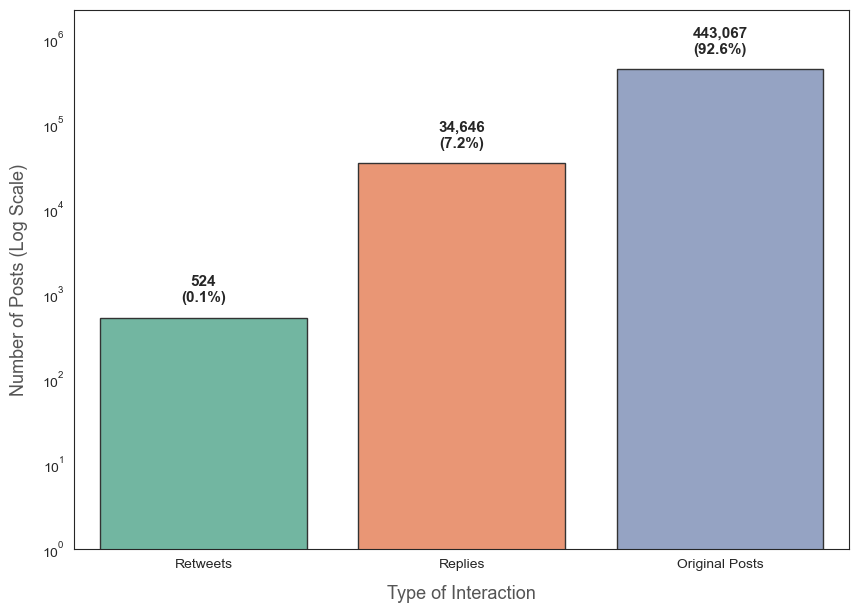

In [20]:
# dataset composition
total_tweets = len(df_clean)
num_retweets = df_retweet.index.nunique()
num_replies = df_reply.index.nunique()
num_original = total_tweets - (num_retweets + num_replies)

labels = ['Retweets', 'Replies', 'Original Posts']
counts = [num_retweets, num_replies, num_original]
percentages = [(v / total_tweets) * 100 for v in counts]

plt.figure(figsize=(10, 7))
sns.set_style("white")

# Assign x to hue and set legend=False as requested by Seaborn
ax = sns.barplot(
    x=labels, 
    y=counts, 
    hue=labels, 
    palette="Set2", 
    legend=False,
    edgecolor=".2"
)

ax.set_yscale("log")
plt.xlabel('Type of Interaction', fontsize=13, labelpad=10, color='#555555')
plt.ylabel('Number of Posts (Log Scale)', fontsize=13, labelpad=10, color='#555555')

# Add numeric and percentage labels
for i, p in enumerate(ax.patches):
    height = p.get_height()
    ax.annotate(f'{int(height):,}\n({percentages[i]:.1f}%)', 
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='center', 
                xytext=(0, 20), # Spostamento verso l'alto
                textcoords='offset points',
                fontsize=11, fontweight='bold')

plt.ylim(1, max(counts) * 5)
plt.savefig('tweet_composition.png', dpi=300, bbox_inches='tight')
plt.show()

**Graph creation**

In [22]:
#GRAPGH RETWEET
G_rt = nx.from_pandas_edgelist(df_retweet, 
                               source='Source', 
                               target='Target', 
                               edge_attr='Weight', 
                               create_using=nx.DiGraph())

print(f"Nodes (users): {G_rt.number_of_nodes()}")
print(f"Labels (relations): {G_rt.number_of_edges()}")
nx.write_gexf(G_rt, "retweet_network.gexf")

Nodes (users): 665
Labels (relations): 524


In [23]:
# In-Degree: Chi è il più retweetato?
in_degree = dict(G_rt.in_degree(weight='Weight'))

# Out-Degree: Chi è il più attivo a rilanciare contenuti?
out_degree = dict(G_rt.out_degree(weight='Weight'))

# PageRank: Chi è l'utente più influente (qualitativamente)?
pagerank = nx.pagerank(G_rt, weight='Weight')

In [24]:
# DataFrame partendo dai dizionari
stats_df = pd.DataFrame({
    'In-Degree': pd.Series(in_degree),
    'Out-Degree': pd.Series(out_degree),
    'PageRank': pd.Series(pagerank)
})

# Invertiamo il mapping: da {'Nome': 'User_1'} a {'User_1': 'Nome'}
reverse_mapping = {v: k for k, v in mapping.items()}

# Aggiungiamo la colonna con il nome reale al DataFrame dei risultati
stats_df['User_Name'] = stats_df.index.map(reverse_mapping)

cols = ['User_Name', 'In-Degree', 'Out-Degree', 'PageRank']
stats_df = stats_df[cols]

# Ordiniamo per PageRank per vedere gli utenti più influenti
top_influencers = stats_df.sort_values(by='PageRank', ascending=False).head(5)

# Visualizziamo la tabella
top_influencers

,User_Name,In-Degree,Out-Degree,PageRank
User_30172,CRN,5,0,0.005923
User_29829,kat,7,0,0.005743
User_33206,Riedl,5,0,0.004292
User_39436,GarethWong,4,0,0.004005
User_35641,Chuck_Carcosa,3,0,0.004005


In [25]:
# Ordiniamo per In-Degree
top_indeg = stats_df.sort_values(by='In-Degree', ascending=False).head(5)

# Visualizziamo la tabella
top_indeg

,User_Name,In-Degree,Out-Degree,PageRank
User_1153,enricomolinari,91,0,0.002878
User_24481,SpirosMargaris,53,0,0.002530
User_468,sonu_monika,42,0,0.001817
User_65,Khulood_Almani,36,0,0.001668
User_2414,efipm,19,0,0.001779


In [26]:
# Ordiniamo per Out-Degree
top_outdeg = stats_df.sort_values(by='Out-Degree', ascending=False).head(5)

# Visualizziamo la tabella
top_outdeg

,User_Name,In-Degree,Out-Degree,PageRank
User_61,ParisFinForum,0,136,0.001128
User_344,itsmuzza2004,0,119,0.001128
User_149,AlanMuttonUK,0,69,0.001128
User_134,naullyn,0,57,0.001128
User_129,tceajmg,0,20,0.001128


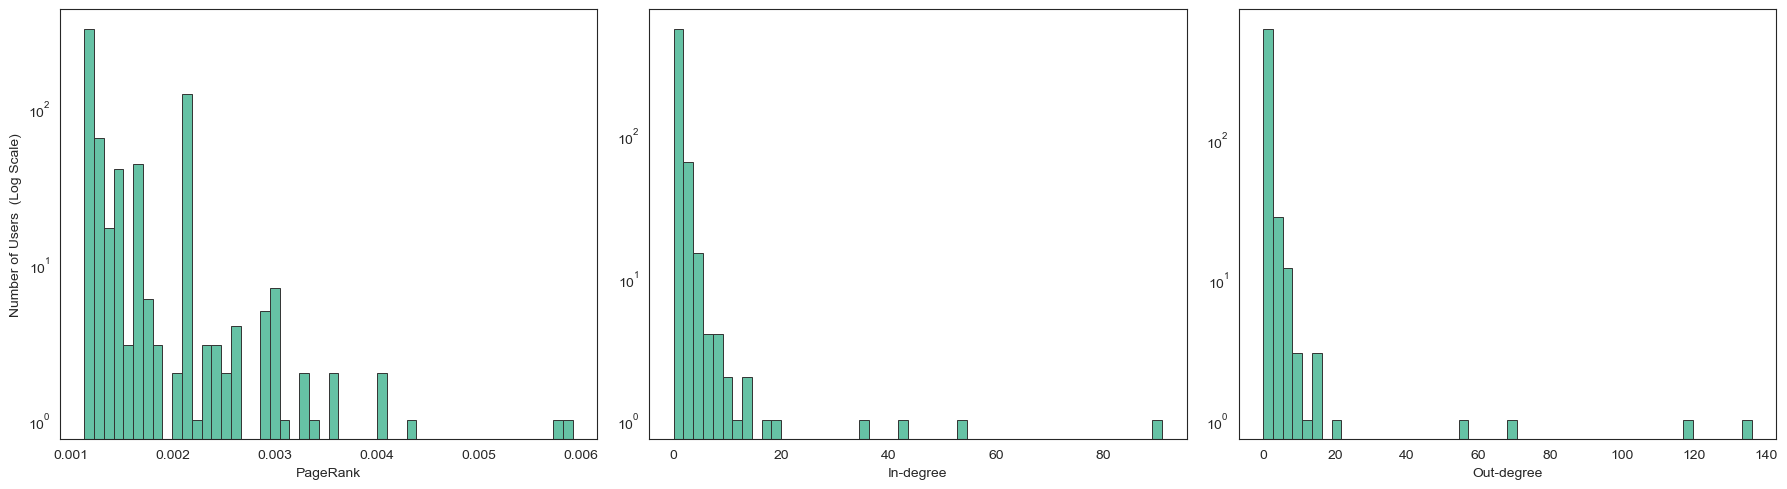

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)
first_color = sns.color_palette("Set2")[0]

# PageRank
axes[0].hist(stats_df['PageRank'], bins=50, color=first_color, log=True, edgecolor=".2", linewidth=0.7)
axes[0].set_xlabel('PageRank')
axes[0].set_ylabel('Number of Users  (Log Scale)')

# In-degree
axes[1].hist(stats_df['In-Degree'], bins=50, color=first_color, log=True, edgecolor=".2", linewidth=0.7)
axes[1].set_xlabel('In-degree')

# Out-degree
axes[2].hist(stats_df['Out-Degree'], bins=50, color=first_color, log=True, edgecolor=".2", linewidth=0.7)
axes[2].set_xlabel('Out-degree')

plt.tight_layout()
plt.savefig('retweet_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

**COMMUNITY DETECTION - RETWEET**

La community detection è volta ad identificare gruppi di nodi (comunità) in un grafo tali che le connessioni intra-gruppo siano dense e le connessioni inter-gruppo siano relativamente scarse. 
La modularità è una funzione obiettivo che misura la qualità di una partizione in comunità confrontando:
- il numero effettivo di archi all’interno delle comunità
- con il numero atteso di archi in un modello nullo

Il metodo di Leiden è un miglioramento di Louvain che garantisce comunità ben connesse.

In [30]:
from collections import Counter
# Louvain richiede un grafo non orientato
G_rt_undirected = G_rt.to_undirected()
# Conversione da NetworkX a igraph
edges = G_rt.edges(data=True)
# Recuperiamo i pesi; usiamo 1.0 se mancano
edges_for_igraph = [(u, v, float(attr.get('Weight', 1))) for u, v, attr in edges]
g_ig_rt = ig.Graph.TupleList(edges_for_igraph, directed=True, edge_attrs=['weight'])

In [31]:
resolutions = [0.01, 0.05, 0.1, 0.5, 1.0, 2.0]
n_runs = 20  # Numero di tentativi per ogni risoluzione
louvain_data = []

print(f"Analisi Multi-run ({n_runs} iterazioni) con LOUVAIN:")

for res in resolutions:
    best_mod_for_res = -1
    best_n_comm_for_res = 0
    
    # Eseguiamo l'algoritmo n_runs volte per questa specifica risoluzione
    for i in range(n_runs):
        # NOTA: random_state=None (default) permette la variazione tra i run
        partition = community_louvain.best_partition(
            G_rt_undirected, 
            resolution=res, 
            weight='Weight'
        )
        
        # Calcolo modularità per questo tentativo
        current_mod = community_louvain.modularity(partition, G_rt_undirected, weight='Weight')

        # Se questo run è migliore dei precedenti, salviamo i dati
        if current_mod > best_mod_for_res:
            best_mod_for_res = current_mod
            best_n_comm_for_res = len(set(partition.values()))

    louvain_data.append({'gamma': res, 'mod_louvain': best_mod_for_res, 'num_louvain': best_n_comm_for_res})
    
    print(f"Risoluzione: {res:<4} | Community: {best_n_comm_for_res:<4} | Miglior Modularità: {best_mod_for_res:.4f}")

df_louvain = pd.DataFrame(louvain_data)

Analisi Multi-run (20 iterazioni) con LOUVAIN:
Risoluzione: 0.01 | Community: 231  | Miglior Modularità: 0.7815
Risoluzione: 0.05 | Community: 223  | Miglior Modularità: 0.7908
Risoluzione: 0.1  | Community: 222  | Miglior Modularità: 0.7995
Risoluzione: 0.5  | Community: 222  | Miglior Modularità: 0.7973
Risoluzione: 1.0  | Community: 182  | Miglior Modularità: 0.8469
Risoluzione: 2.0  | Community: 184  | Miglior Modularità: 0.8380


In [32]:
# METODO 1: LEIDEN CON OTTIMIZZAZIONE MODULARITÀ STANDARD 
# Questo metodo non accetta resolution_parameter, usa il default gamma=1.0
partition = la.find_partition(
    g_ig_rt, 
    la.ModularityVertexPartition,
    weights='weight'
)

print("Risultati Modularità Standard")
print(f"Number of communities: {len(partition)}")
print(f"Modularity: {partition.modularity:.4f}")

Risultati Modularità Standard
Number of communities: 182
Modularity: 0.9313


In [33]:
resolutions = [0.01, 0.05, 0.1, 0.5, 1.0, 2.0]
n_runs = 20  # Numero di esecuzioni per ogni risoluzione 

print(f"Analisi Multi-run ({n_runs} iterazioni) con LEIDEN RB:")

for res in resolutions:
    best_mod_for_res = -1
    best_partition = None

    for i in range(n_runs):
        # Eseguiamo Leiden (senza seed fisso per permettere la variazione stocastica)
        # Usiamo n_iterations=-1 per far convergere l'algoritmo al meglio
        current_partition = la.find_partition(
            g_ig_rt, 
            la.RBConfigurationVertexPartition, 
            weights='weight', 
            resolution_parameter=res,
            n_iterations=-1
        )
        
        # Valutiamo la modularità del run corrente
        current_mod = current_partition.modularity
        
        if current_mod > best_mod_for_res:
            best_mod_for_res = current_mod
            best_partition = len(current_partition)

    print(f"Risolutore: {res:<5} | Community: {best_partition:<4} | Modularity: {best_mod_for_res:.4f}")

Analisi Multi-run (20 iterazioni) con LEIDEN RB:
Risolutore: 0.01  | Community: 173  | Modularity: 0.9119
Risolutore: 0.05  | Community: 173  | Modularity: 0.9119
Risolutore: 0.1   | Community: 173  | Modularity: 0.9119
Risolutore: 0.5   | Community: 179  | Modularity: 0.9410
Risolutore: 1.0   | Community: 182  | Modularity: 0.9313
Risolutore: 2.0   | Community: 185  | Modularity: 0.9173


In [34]:
resolutions = [0.001, 0.005, 0.01, 0.05, 0.07, 0.1]
n_runs = 20  # Numero di esecuzioni per trovare l'ottimo locale (Practical Tip)

print(f"Analisi Multi-run ({n_runs} iterazioni) con LEIDEN CPM")

best_overall_partition = None
max_modularity_seen = -1

for res in resolutions:
    best_mod_for_res = -1
    best_part_for_res = None
    
    for i in range(n_runs):
        # Eseguiamo il run senza seed fisso per esplorare lo spazio delle soluzioni
        current_partition = la.find_partition(
            g_ig_rt,
            la.CPMVertexPartition,
            weights='weight',
            resolution_parameter=res,
            n_iterations=-1 # Assicura la massima ottimizzazione in ogni run
        )
        
        # Calcoliamo la modularità classica per validare la qualità della partizione
        current_mod = g_ig_rt.modularity(current_partition.membership, weights='weight')
        
        if current_mod > best_mod_for_res:
            best_mod_for_res = current_mod
            best_part_for_res = current_partition
            
    # Salviamo la partizione migliore in assoluto tra tutte le risoluzioni
    if best_mod_for_res > max_modularity_seen:
        max_modularity_seen = best_mod_for_res
        best_overall_partition = best_part_for_res
    
    print(f"Risolutore: {res:<6} | Community: {len(best_part_for_res):<4} | Modularity: {best_mod_for_res:.4f}")

Analisi Multi-run (20 iterazioni) con LEIDEN CPM
Risolutore: 0.001  | Community: 176  | Modularity: 0.7524
Risolutore: 0.005  | Community: 184  | Modularity: 0.7777
Risolutore: 0.01   | Community: 196  | Modularity: 0.7687
Risolutore: 0.05   | Community: 238  | Modularity: 0.7721
Risolutore: 0.07   | Community: 251  | Modularity: 0.7579
Risolutore: 0.1    | Community: 281  | Modularity: 0.7216


Spiegazione:
- *Leiden classico*: confronta il numero di archi dentro una comunità con quelli che ci si aspetterebbe se i legami fossero creati a caso. Parametro $\gamma$ fisso a 1. In reti grandi, tende ad accorpare forzatamente comunità piccole in una grande, anche se non hanno nulla in comune, solo per far quadrare i conti matematici globali.
- *Leiden RB*: è identica alla modularità normale, ma introduce il parametro di risoluzione $\gamma$.
- *Leiden CPM*: non fa confronti con modelli casuali. Si basa su una soglia di densità fissa. Una comunità è tale se la densità di legami interni è superiore a $\gamma$ e quella esterna è inferiore a $\gamma$. Il parametro $\gamma$ rappresenta la densità minima richiesta.

*ANALISI GRAFICA*

In [37]:
data = []
resolutions = np.linspace(0, 2.0, 20+1)
n_runs = 20

for res in resolutions:
    for run in range(n_runs):

        # Louvain
        part_louvain = community_louvain.best_partition(
            G_rt_undirected,
            resolution=res,
            weight='Weight'
        )
        mod_louvain = community_louvain.modularity(
            part_louvain,
            G_rt_undirected,
            weight='Weight'
        )
        num_louvain = len(set(part_louvain.values()))

        # Leiden
        part_leiden = la.find_partition(
            g_ig_rt,
            la.RBConfigurationVertexPartition,
            weights='weight',
            resolution_parameter=res,
            n_iterations=-1
        )
        mod_leiden = part_leiden.modularity
        num_leiden = len(part_leiden)
        
        data.append({
            'Resolution': res,
            'Mod_Louvain': mod_louvain,
            'Num_Louvain': num_louvain,
            'Mod_Leiden': mod_leiden,
            'Num_Leiden': num_leiden
        })

In [38]:
df = pd.DataFrame(data)
stats = df.groupby('Resolution').agg(['mean', 'std']).reset_index()

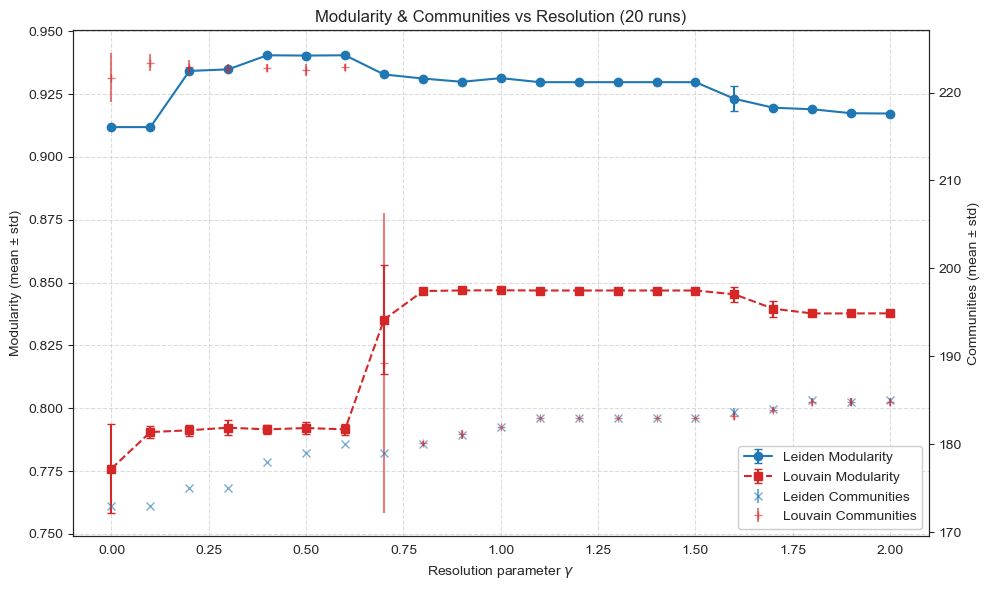

In [39]:
stats.columns = [
    '_'.join(col).strip('_') if isinstance(col, tuple) else col
    for col in stats.columns
]


fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()

# Modularità (mean ± std)
ax1.errorbar(stats['Resolution'], stats['Mod_Leiden_mean'], yerr=stats['Mod_Leiden_std'], 
             fmt='-o', capsize=3, label='Leiden Modularity', color='tab:blue')

ax1.errorbar(stats['Resolution'], stats['Mod_Louvain_mean'], yerr=stats['Mod_Louvain_std'], 
             fmt='--s', capsize=3, label='Louvain Modularity', color='tab:red')

# Numero community (mean ± std)
ax2.errorbar(stats['Resolution'], stats['Num_Leiden_mean'], yerr=stats['Num_Leiden_std'], fmt='x', color='tab:blue', alpha=0.6, label='Leiden Communities')

ax2.errorbar(stats['Resolution'], stats['Num_Louvain_mean'], yerr=stats['Num_Louvain_std'], fmt='+', color='tab:red', alpha=0.6, label='Louvain Communities')


# Formattazione
ax1.set_xlabel(r'Resolution parameter $\gamma$')
ax1.set_ylabel('Modularity (mean ± std)')
ax2.set_ylabel('Communities (mean ± std)')
ax1.set_title('Modularity & Communities vs Resolution (20 runs)')
ax1.grid(True, linestyle='--', alpha=0.7)
ax2.grid(False)
ax1.set_axisbelow(True)

# Legenda unica
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='lower right',
          frameon=True, fancybox=True,framealpha=1)

plt.tight_layout()
plt.savefig('modularity_vs_resolution.png', dpi=300, bbox_inches='tight')
plt.show()

Per l’analisi finale è stato selezionato un parametro di risoluzione $\gamma = 1.0$. Tale scelta è motivata da un’analisi di stabilità che evidenzia, in corrispondenza di questo valore, una modularità elevata (Louvain: 0.846922; Leiden: 0.931341) e una maggiore robustezza della partizione rispetto a variazioni del parametro di risoluzione. Sebbene valori di $\gamma$ compresi tra 0.50 e 0.75 producano una modularità leggermente superiore, la differenza risulta marginale e associata a una minore stabilità delle community. Pertanto, $\gamma = 1.0$ rappresenta un compromesso tra qualità della partizione e robustezza strutturale.

In [41]:
print(stats)

    Resolution  Mod_Louvain_mean  Mod_Louvain_std  Num_Louvain_mean  \
0          0.0          0.775977     1.757208e-02            221.70   
1          0.1          0.790509     2.357771e-03            223.40   
2          0.2          0.791227     2.291040e-03            222.90   
3          0.3          0.792255     2.897642e-03            222.70   
4          0.4          0.791582     1.805011e-03            222.80   
5          0.5          0.792129     2.268055e-03            222.60   
6          0.6          0.791579     2.089851e-03            222.85   
7          0.7          0.835264     2.160434e-02            189.25   
8          0.8          0.846615     1.004745e-05            180.10   
9          0.9          0.846869     8.890718e-05            181.10   
10         1.0          0.846922     7.204078e-17            182.00   
11         1.1          0.846838     6.238915e-17            183.00   
12         1.2          0.846838     7.641079e-17            183.00   
13    

**ANALISI COMMUNITY RETWEET**

stessa funzione di prima ma prendo solo risolutore = 1.0

In [44]:
# Scegliamo la risoluzione che abbiamo stabilito essere la migliore
target_res = 1.0
n_runs = 20

best_mod = -1
final_partition_object = None

for i in range(n_runs):
    current_partition = la.find_partition(
        g_ig_rt, 
        la.RBConfigurationVertexPartition, 
        weights='weight', 
        resolution_parameter=target_res,
        n_iterations=-1
    )
    
    if current_partition.modularity > best_mod:
        best_mod = current_partition.modularity
        final_partition_object = current_partition

print(f"Miglior Modularità trovata: {best_mod:.4f}")
print(f"Numero di community identificate: {len(final_partition_object)}")

Miglior Modularità trovata: 0.9313
Numero di community identificate: 182


In [45]:
communities = final_partition_object.membership
n_communities = len(set(communities))
print(f"Numero totale di retweet community: {n_communities}")

Numero totale di retweet community: 182


In [46]:
from collections import Counter

community_sizes = Counter(communities)
community_df = pd.DataFrame([
    {'community_id': comm_id, 'size': size}
    for comm_id, size in community_sizes.items()
]).sort_values('size', ascending=False)

print("\nTop 10 community per dimensione:")
print(community_df.head(10))


Top 10 community per dimensione:
     community_id  size
31              0    41
26              1    29
16              2    27
27              3    26
78              4    20
48              5    18
154             6    14
32              7    13
6               8    12
30              9    10


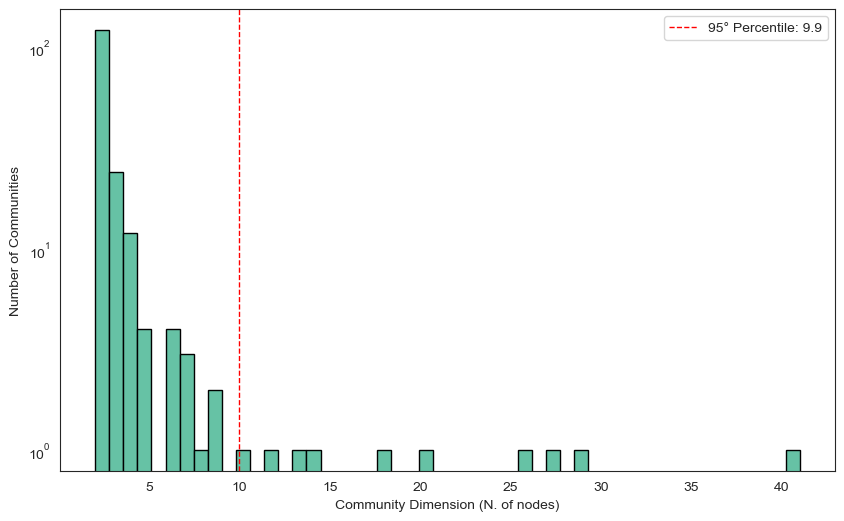

In [47]:
# 1. Grafico a barre di tutte le 182 community
p95_value = community_df['size'].quantile(0.95)
first_color = sns.color_palette("Set2")[0]
plt.figure(figsize=(10, 6))
plt.hist(community_df['size'], bins=50, color=first_color, log=True, edgecolor='black')
plt.axvline(p95_value, color='red', linestyle='--', linewidth=1, 
            label=f'95° Percentile: {p95_value:.1f}')
plt.xlabel('Community Dimension (N. of nodes)')
plt.ylabel('Number of Communities')
plt.legend()
plt.savefig('comm_ret.png', dpi=300, bbox_inches='tight')
plt.show()

Non facciamo analisi su tutte 182 community, scegliamo un criterio per selezionarle: soglia 95° percentile

In [49]:
sizes = community_df['size'].values
# Definizione del 95° percentile
threshold = np.percentile(sizes, 95)
print(f"Soglia (95° percentile): {threshold:.2f} nodi")

# Identificazione delle community significative
# Creiamo una lista di tuple (id_community, dimensione)
significant_comms = []
for comm_id, size in community_sizes.items():
    if size >= threshold:
        significant_comms.append((comm_id, size))

# Ordiniamo per dimensione decrescente
significant_comms.sort(key=lambda x: x[1], reverse=True)

print(f"Community totali: {len(sizes)}")
print(f"Community sopra la soglia: {len(significant_comms)}")
for cid, s in significant_comms:
    print(f"ID Community: {cid} | Dimensione: {s}")

significant_df = community_df[community_df['size'] >= threshold].copy()

Soglia (95° percentile): 9.95 nodi
Community totali: 182
Community sopra la soglia: 10
ID Community: 0 | Dimensione: 41
ID Community: 1 | Dimensione: 29
ID Community: 2 | Dimensione: 27
ID Community: 3 | Dimensione: 26
ID Community: 4 | Dimensione: 20
ID Community: 5 | Dimensione: 18
ID Community: 6 | Dimensione: 14
ID Community: 7 | Dimensione: 13
ID Community: 8 | Dimensione: 12
ID Community: 9 | Dimensione: 10


In [50]:
# Creiamo un dizionario Nodo -> Community per velocizzare i calcoli
node_to_comm = {i: comm for i, comm in enumerate(communities)}
analysis_results = []

print(f"\n{'ID':>3} | {'Size':>4} | {'EI Index':>8} | {'Insular':>7} | {'Top 3 Influencers (Interni)':<40}")
print("-" * 90)

for cid in significant_df['community_id']:
    # Estraiamo i nodi appartenenti a questa specifica community
    nodes_in_comm = [i for i, comm in enumerate(communities) if comm == cid]
    
    # CALCOLO E-I INDEX PESATO 
    """
    Formula:
    --------
    E-I Index = (External_Weight - Internal_Weight) / (External_Weight + Internal_Weight)
    
    Range: [-1, +1]
    -1 = massima omofilia (solo link interni) → ECHO CHAMBER
    +1 = massima eterofilia (solo link esterni) → BRIDGE COMMUNITY
     0 = bilanciato (50% interni, 50% esterni)
    
    IMPORTANTE: mode='out' per evitare di contare gli archi due volte
    """
    
    internal_weight = 0
    external_weight = 0
    
    for node in nodes_in_comm:
        # MODE='OUT' per evitare duplicati
        out_edges = g_ig_rt.es.select(_source=node)
        
        for edge in out_edges:
            target = edge.target
            weight = edge['weight']  # Usa il peso dei retweet
            
            if node_to_comm[target] == cid:
                internal_weight += weight
            else:
                external_weight += weight
    
    # Formula E-I Index: (E - I) / (E + I)
    denom = (external_weight + internal_weight)
    ei_index = (external_weight - internal_weight) / denom if denom > 0 else 0
    
    # Calcola anche l'Insularity -> formation of homogeneous, and isolated groups or "bubbles," characterized by high homophily
    # Insularity = percentuale di interazioni interne
    # 0% = completamente aperta, 100% = completamente chiusa
    insularity = (internal_weight / denom) if denom > 0 else 0
    
    # IDENTIFICAZIONE LEADER (In-Degree nel sottografo)
    subgraph = g_ig_rt.subgraph(nodes_in_comm)
    # Calcoliamo la forza (strength) basata sui pesi dei retweet ricevuti
    in_strengths = subgraph.strength(mode='in', weights='weight')
    
    # Accoppiamo nomi e punteggi, poi ordiniamo
    leader_list = sorted(zip(subgraph.vs['name'], in_strengths), key=lambda x: x[1], reverse=True)
    top_3_names = [name for name, score in leader_list[:3]]
    leaders_str = ", ".join(top_3_names)
    
    # RISULTATI
    analysis_results.append({
        'ID': cid,
        'Size': len(nodes_in_comm),
        'EI_Index': ei_index,
        'Insularity': insularity,
        'Internal_Weight': internal_weight,
        'External_Weight': external_weight,
        'Leaders': leaders_str
    })
    
    print(f"{int(cid):>3} | {len(nodes_in_comm):>4} | {ei_index:>8.3f} | {insularity:>6.1%} | {leaders_str:<40}")


 ID | Size | EI Index | Insular | Top 3 Influencers (Interni)             
------------------------------------------------------------------------------------------
  0 |   41 |   -0.438 |  71.9% | User_25163, User_3949, User_24642       
  1 |   29 |   -1.000 | 100.0% | User_24852, User_25188, User_33461      
  2 |   27 |   -0.857 |  92.9% | User_31550, User_25364, User_33756      
  3 |   26 |   -0.938 |  96.9% | User_33206, User_24476, User_31030      
  4 |   20 |   -1.000 | 100.0% | User_27791, User_24543, User_28509      
  5 |   18 |   -1.000 | 100.0% | User_29829, User_25887, User_29053      
  6 |   14 |   -1.000 | 100.0% | User_32912, User_34031, User_120        
  7 |   13 |   -0.973 |  98.6% | User_1153, User_24481, User_2414        
  8 |   12 |   -0.733 |  86.7% | User_3106, User_50, User_12952          
  9 |   10 |   -1.000 | 100.0% | User_33805, User_39410, User_21961      


EI-Indez = -1 indica comunità permettamente isolate. La comunità 0, quella di dimensione più grande, è la più "aperta all'esterno. I top utenti agiscono come mediatori. 
- ipfconline1: utente che si occupa di condividere contenuti relativi alla trasformazione digitale, innovazione, intelligenza artificiale, IoT e leadership digitale.
- PawlowskiMario: utente attivo che si definisce come "I’m the inventor of the Hyparadox Theory — a concept where hypocrisy and paradox collide, exposing the glitch in how humans think, act, and self-destruct".
- jblefevre60: utente attivo "Head of Digital & Socialmedia, CDO, Influencer, Growth-Hacker"

*Di cosa parlano le community? Analisi hashtag*

In [53]:
# Inverte il dizionario: da {'Mario': 'User_1'} a {'User_1': 'Mario'}
reverse_mapping = {v: k for k, v in mapping.items()}

In [54]:
# DataFrame che mappa ogni utente alla sua community
df_communities = pd.DataFrame({
    'user_id': g_ig_rt.vs['name'],
    'community_id': final_partition_object.membership
})

In [55]:
df_communities['real_name'] = df_communities['user_id'].map(reverse_mapping)

In [56]:
# 1. Filtriamo solo i retweet dalla colonna 'edge_info'
df_retweet_raw = df_edges_raw[df_edges_raw['edge_info'].apply(lambda x: x[2] == 'retweet')]

# 2. Creiamo il DataFrame finale espandendo la tupla e aggiungendo il testo
df_retweet = pd.DataFrame(
    df_retweet_raw['edge_info'].tolist(), 
    columns=['Source', 'Target', 'Type'], 
    index=df_retweet_raw.index
)

# 3. Aggiungiamo la colonna del testo originale dal DataFrame pulito
df_retweet['Tweet'] = df_retweet_raw['Tweet']
df_retweet['Date'] = df_clean.loc[df_retweet_raw.index, 'Date']  # Usa gli indici originali

In [57]:
df_retweet['Source_ID'] = df_retweet['Source'].map(mapping)
df_retweet['Target_ID'] = df_retweet['Target'].map(mapping)

# 3. Ora facciamo il merge con df_communities usando gli ID
# Assumendo che df_communities abbia ['user_id', 'community_id']
df_merged = df_retweet.merge(
    df_communities, 
    left_on='Source_ID', 
    right_on='user_id', 
    how='inner'
)

In [58]:
df_merged = df_merged.drop(columns=['user_id'])

In [59]:
# Uniamo i due DataFrame basandoci sul nome utente
#df_merged = df_retweet.merge(df_communities, left_on='Source', right_on='user', how='inner')

print(f"Tweet totali mappati: {len(df_merged)}")

Tweet totali mappati: 901


In [60]:
from collections import Counter

def get_top_hashtags(text_series, top_n=10):
    # Funzione veloce per estrarre hashtag dal testo
    hashtags = text_series.str.findall(r'#(\w+)').explode().str.lower()
    return hashtags.value_counts().head(top_n)

# Analizziamo le community del significant_df (community sopra al 95° percentile)
significant_df_clean = significant_df.reset_index()
for cid in significant_df['community_id']:
    # Filtriamo i tweet della community specifica
    comm_tweets = df_merged[df_merged['community_id'] == cid]['Tweet']
    
    top_tags = get_top_hashtags(comm_tweets)
    
    print(f"\n Hashtag Dominanti Community {cid}")
    if not top_tags.empty:
        print(top_tags)
    else:
        print("Nessun hashtag trovato in questa community.")


 Hashtag Dominanti Community 0
Tweet
chatgpt                   186
ai                        140
machinelearning            68
artificialintelligence     51
fintech                    42
generativeai               42
deeplearning               27
nlp                        23
marketing                  23
metaverse                  21
Name: count, dtype: int64

 Hashtag Dominanti Community 1
Tweet
chatgpt           28
ai                 4
infosec            3
emacs              3
vim                3
llm                2
retrocomputing     2
comic              2
business           2
python             1
Name: count, dtype: int64

 Hashtag Dominanti Community 2
Tweet
chatgpt              28
ai                    7
stochasticparrots     3
aiethics              2
highereducation       2
languagemodels        2
conman                2
resistingai           2
openai                2
nlp                   1
Name: count, dtype: int64

 Hashtag Dominanti Community 3
Tweet
chatgpt       33
edt

Ci sono hashtag prettamente dominanti (in quanto il dataset è stato scaricato in base a questi) come: chatgpt, ai, openai, artificialintelligence -> proviamo a rimuoverli e vedere i topic dominanti 

In [62]:
# Lista di hashtag da ignorare
removed_hashtag = {'chatgpt', 'ai', 'openai', 'artificialintelligence'}

def get_top_hashtags_filtered(text_series, top_n=10):
    # 1. Estrazione e normalizzazione (minuscolo)
    hashtags = text_series.str.findall(r'#(\w+)').explode().str.lower()
    
    # 2. Filtriamo i termini nella blacklist
    # Usiamo .dropna() per sicurezza e ~ .isin() per escludere la blacklist
    filtered_hashtags = hashtags[~hashtags.isin(removed_hashtag)].dropna()
    
    # 3. Conteggio e formattazione
    return filtered_hashtags.value_counts().head(top_n)

for cid in significant_df['community_id']:
    # Filtriamo i tweet della community specifica
    comm_tweets = df_merged[df_merged['community_id'] == cid]['Tweet']
    
    top_tags = get_top_hashtags_filtered(comm_tweets)
    
    print(f"\n Hashtag Dominanti Community {cid}")
    if not top_tags.empty:
        print(top_tags)
    else:
        print("Nessun hashtag trovato in questa community.")


 Hashtag Dominanti Community 0
Tweet
machinelearning    68
fintech            42
generativeai       42
deeplearning       27
nlp                23
marketing          23
metaverse          21
innovation         20
tech               20
technology         18
Name: count, dtype: int64

 Hashtag Dominanti Community 1
Tweet
infosec           3
emacs             3
vim               3
llm               2
retrocomputing    2
comic             2
business          2
python            1
1                 1
generativeai      1
Name: count, dtype: int64

 Hashtag Dominanti Community 2
Tweet
stochasticparrots    3
aiethics             2
highereducation      2
languagemodels       2
conman               2
resistingai          2
thesimpsons          1
d                    1
elonmusk             1
privacy              1
Name: count, dtype: int64

 Hashtag Dominanti Community 3
Tweet
edtech        13
education      7
teaching       5
highered       3
edchat         3
edutooter      3
learning       3
e

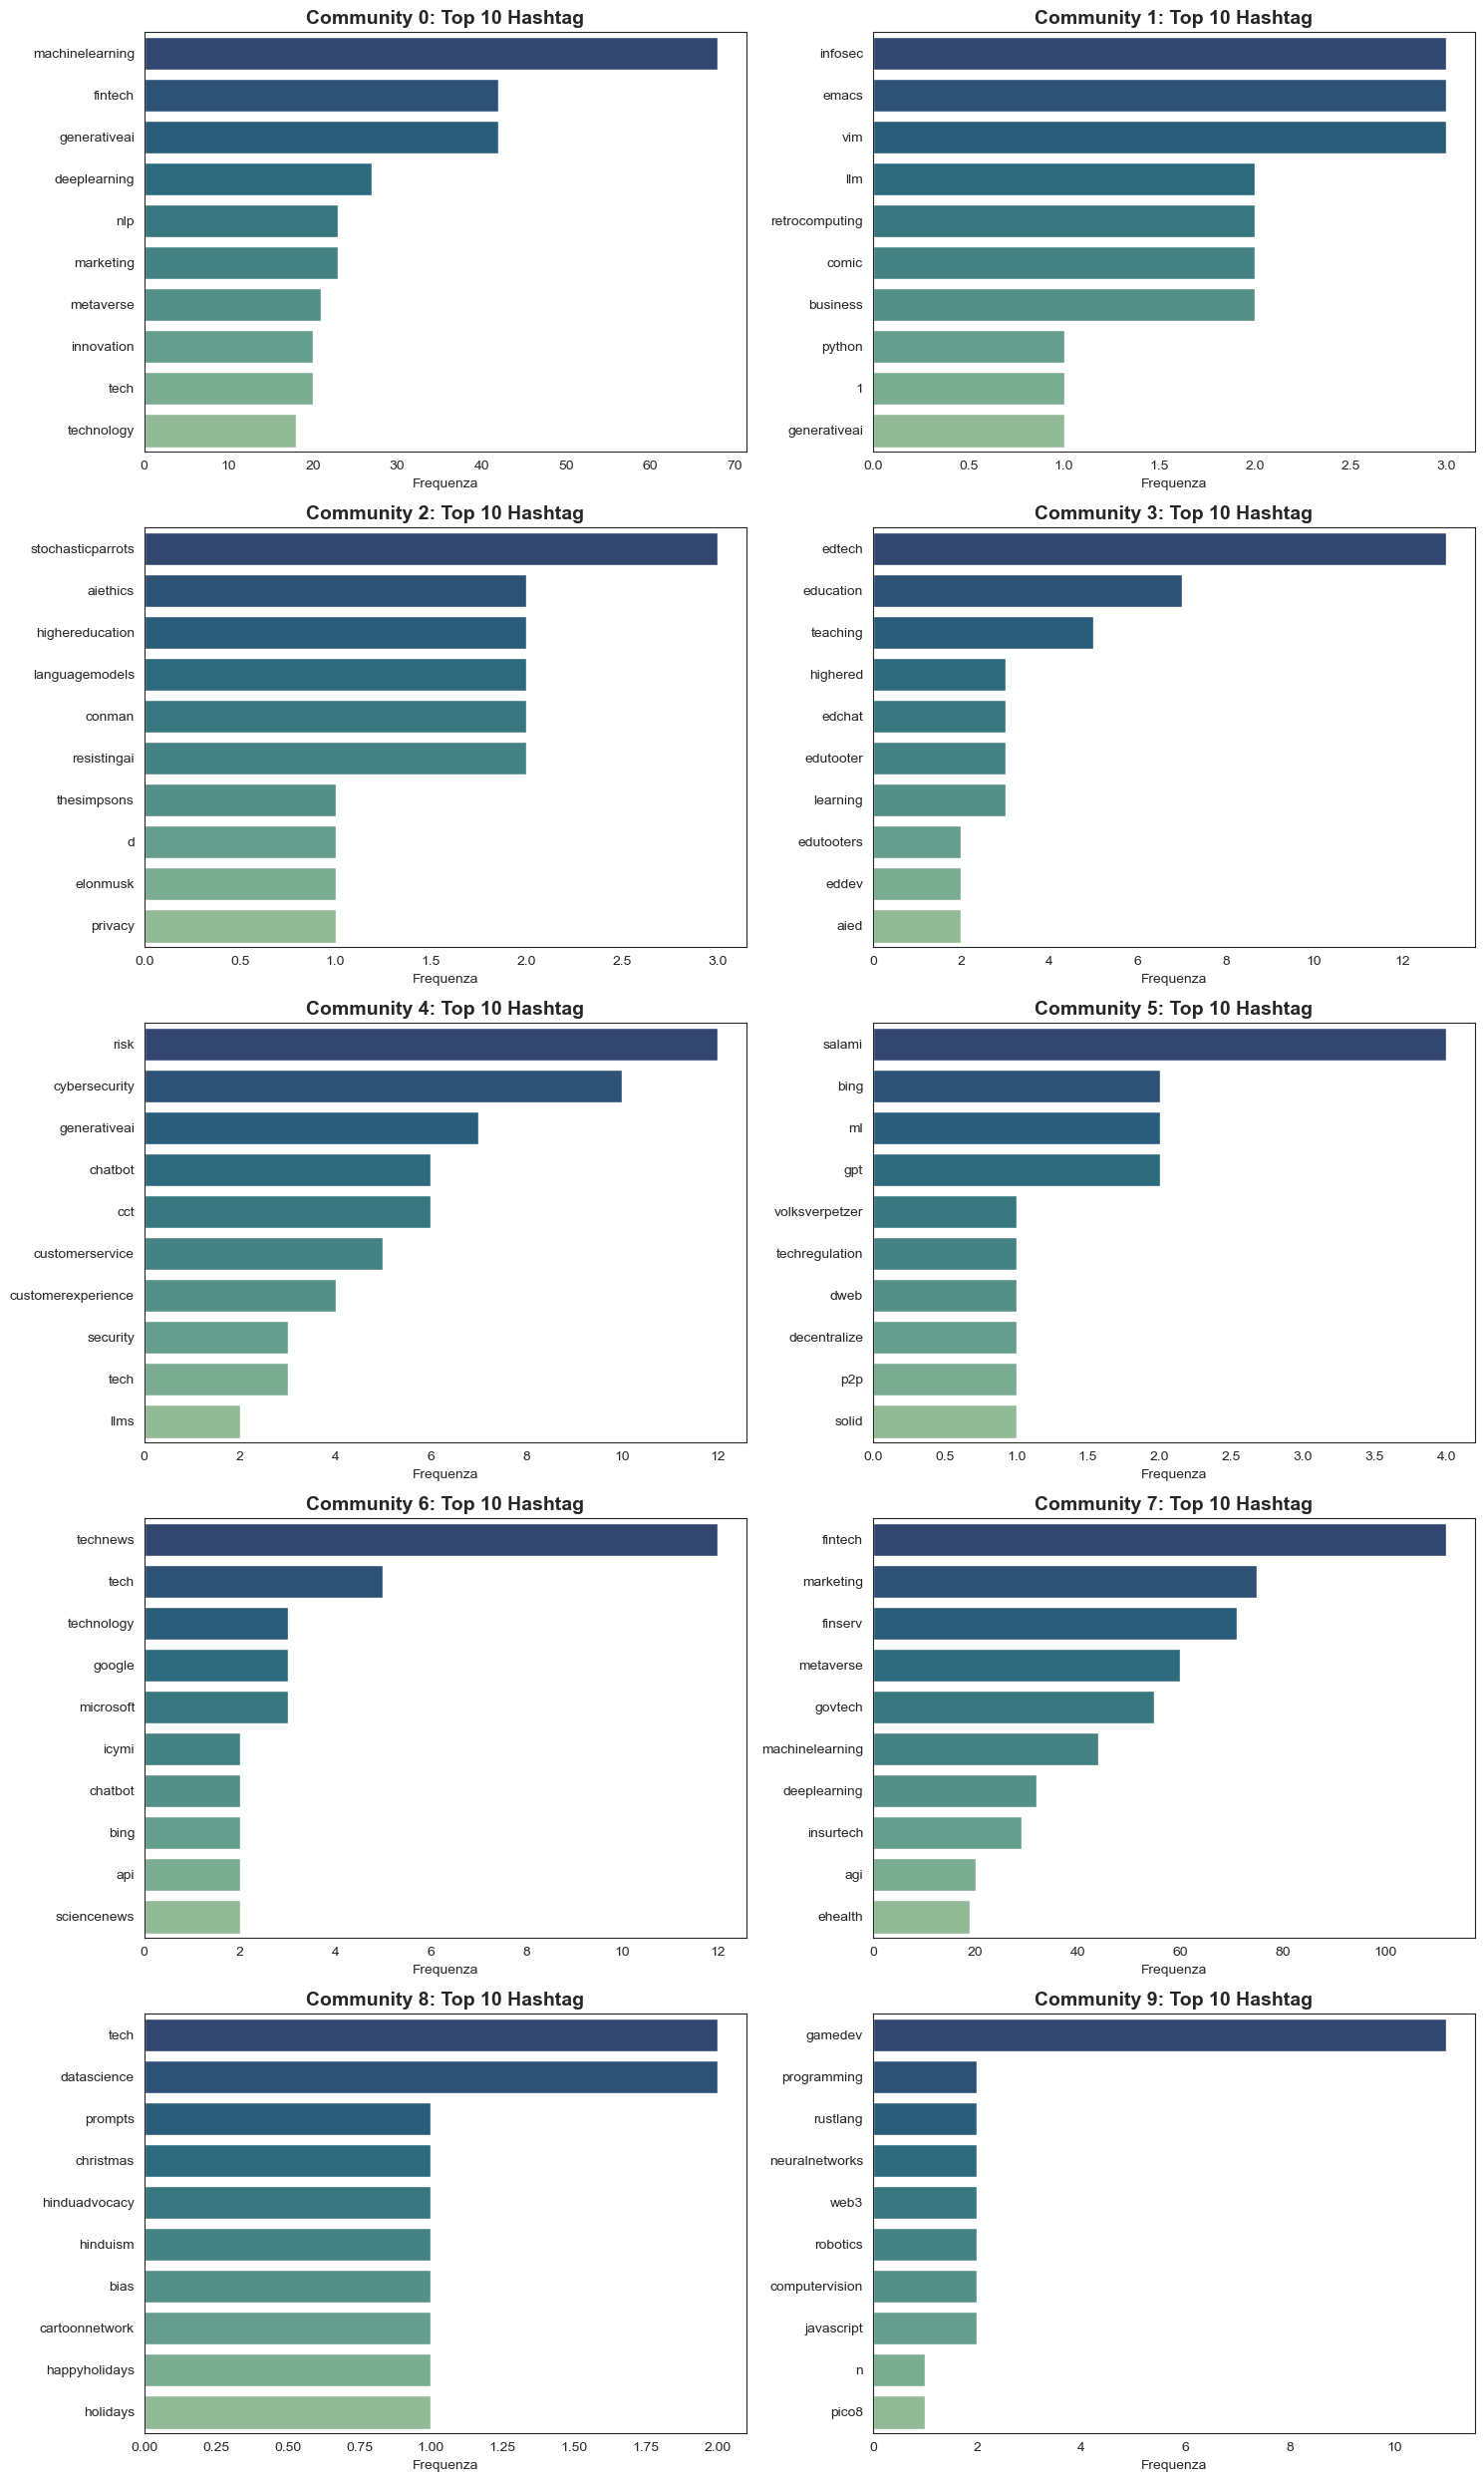

In [63]:
top_comms = significant_df['community_id'].tolist()

# Configuriamo la griglia (5 righe x 2 colonne)
fig, axes = plt.subplots(5, 2, figsize=(15, 25))
axes = axes.flatten()

for i, cid in enumerate(top_comms):
    # Filtriamo e normalizziamo gli hashtag (come abbiamo fatto prima)
    comm_tweets = df_merged[df_merged['community_id'] == cid]['Tweet']
    hashtags = comm_tweets.str.findall(r'#(\w+)').explode().str.lower()
    
    # Rimuoviamo hashtag comuni
    removed_hashtag = {'chatgpt', 'ai', 'openai', 'artificialintelligence'}
    filtered_tags = hashtags[~hashtags.isin(removed_hashtag)].dropna()
    
    # Prendiamo i top 10
    top_10 = filtered_tags.value_counts().head(10)
    
    # Creazione del grafico a barre
    sns.barplot(x=top_10.values, y=top_10.index,hue=top_10.index, ax=axes[i], palette="crest_r")
    
    axes[i].set_title(f"Community {cid}: Top 10 Hashtag", fontsize=14, fontweight='bold')
    axes[i].set_xlabel("Frequenza")
    axes[i].set_ylabel("")

# Pulizia del layout
plt.tight_layout()
plt.savefig('hashtag_communities.png', dpi=300)

plt.show()

SALAMI : Systematic Approaches to Learning Algorithms and Machine Inference. 

*Applichiamo TF-IDF*

In [66]:
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Raggruppiamo tutti gli hashtag di ogni community in una "frase" unica
comm_docs = []
ids = significant_df['community_id'].tolist()

for cid in ids:
    # Estraiamo tutti gli hashtag della community e li uniamo in una stringa
    tweets = df_merged[df_merged['community_id'] == cid]['Tweet']
    tags = tweets.str.findall(r'#(\w+)').explode().str.lower().dropna()
    comm_docs.append(" ".join(tags))

# 2. Applichiamo TF-IDF
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(comm_docs)
feature_names = vectorizer.get_feature_names_out()

print(f"\n{'ID':>3} | {'Hashtag (Top 10 per TF-IDF Score)':<80}")
print("-" * 120)

for i, cid in enumerate(ids):
    # Otteniamo i punteggi della riga i (community i)
    scores = tfidf_matrix.getrow(i).toarray()[0]
    
    # Troviamo i 5 indici con il valore TF-IDF più alto
    top_indices = scores.argsort()[-10:][::-1]
    
    # Creiamo la lista di hashtag con il relativo punteggio (arrotondato)
    top_terms = [f"{feature_names[idx]} ({scores[idx]:.3f})" for idx in top_indices if scores[idx] > 0]
    
    terms_str = ", ".join(top_terms)
    print(f"{int(cid):>3} | {terms_str}")

print("-" * 120)


 ID | Hashtag (Top 10 per TF-IDF Score)                                               
------------------------------------------------------------------------------------------------------------------------
  0 | chatgpt (0.552), ai (0.415), machinelearning (0.324), fintech (0.287), artificialintelligence (0.220), generativeai (0.200), deeplearning (0.161), marketing (0.157), metaverse (0.125), nlp (0.122)
  1 | chatgpt (0.816), emacs (0.236), vim (0.236), infosec (0.201), retrocomputing (0.158), comic (0.158), business (0.117), ai (0.117), llm (0.104), retro (0.079)
  2 | chatgpt (0.831), stochasticparrots (0.241), ai (0.208), conman (0.160), resistingai (0.160), highereducation (0.160), languagemodels (0.136), aiethics (0.119), trek (0.080), tng (0.080)
  3 | chatgpt (0.629), edtech (0.498), teaching (0.258), education (0.239), ai (0.210), learning (0.155), edchat (0.155), edutooter (0.155), highered (0.155), aied (0.103)
  4 | risk (0.519), chatgpt (0.448), cybersecurity (0.322), 

TF_IDF senza termini comuni

In [68]:
removed_hashtag = {'chatgpt', 'ai', 'openai', 'artificialintelligence'}

# 2. Raggruppamento hashtag filtrati per community
comm_docs = []
ids = significant_df['community_id'].tolist()

for cid in ids:
    tweets = df_merged[df_merged['community_id'] == cid]['Tweet']
    # Estraiamo gli hashtag
    tags = tweets.str.findall(r'#(\w+)').explode().str.lower().dropna()
    # Applichiamo il filtro
    filtered_tags = tags[~tags.isin(removed_hashtag)]
    comm_docs.append(" ".join(filtered_tags))

# 3. Calcolo TF-IDF
# Usiamo stop_words='english' come ulteriore sicurezza se ci fossero termini comuni residui
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(comm_docs)
feature_names = vectorizer.get_feature_names_out()

# 4. Output testuale formattato
print(f"\n{'ID':>3} | {'Hashtag (TF-IDF Score - Filtered)':<80}")
print("-" * 110)

for i, cid in enumerate(ids):
    scores = tfidf_matrix.getrow(i).toarray()[0]
    top_indices = scores.argsort()[-10:][::-1]
    
    # Filtriamo per assicurarci di non stampare termini con score zero
    top_terms = [f"{feature_names[idx]} ({scores[idx]:.3f})" for idx in top_indices if scores[idx] > 0]
    
    terms_str = ", ".join(top_terms)
    print(f"{int(cid):>3} | {terms_str}")

print("-" * 110)


 ID | Hashtag (TF-IDF Score - Filtered)                                               
--------------------------------------------------------------------------------------------------------------
  0 | machinelearning (0.472), fintech (0.417), generativeai (0.292), deeplearning (0.235), marketing (0.229), metaverse (0.183), nlp (0.178), agi (0.139), coding (0.139), innovation (0.139)
  1 | vim (0.418), emacs (0.418), infosec (0.355), retrocomputing (0.279), comic (0.279), business (0.207), llm (0.184), retro (0.139), twittermigration (0.139), code (0.139)
  2 | stochasticparrots (0.472), highereducation (0.315), conman (0.315), resistingai (0.315), languagemodels (0.268), aiethics (0.234), opensource (0.157), laion (0.157), marxist (0.157), dungeonsanddragons (0.157)
  3 | edtech (0.666), teaching (0.344), education (0.319), edutooter (0.207), learning (0.207), edchat (0.207), highered (0.207), aied (0.138), edutooters (0.138), eddev (0.138)
  4 | risk (0.611), cybersecurity (0.379)

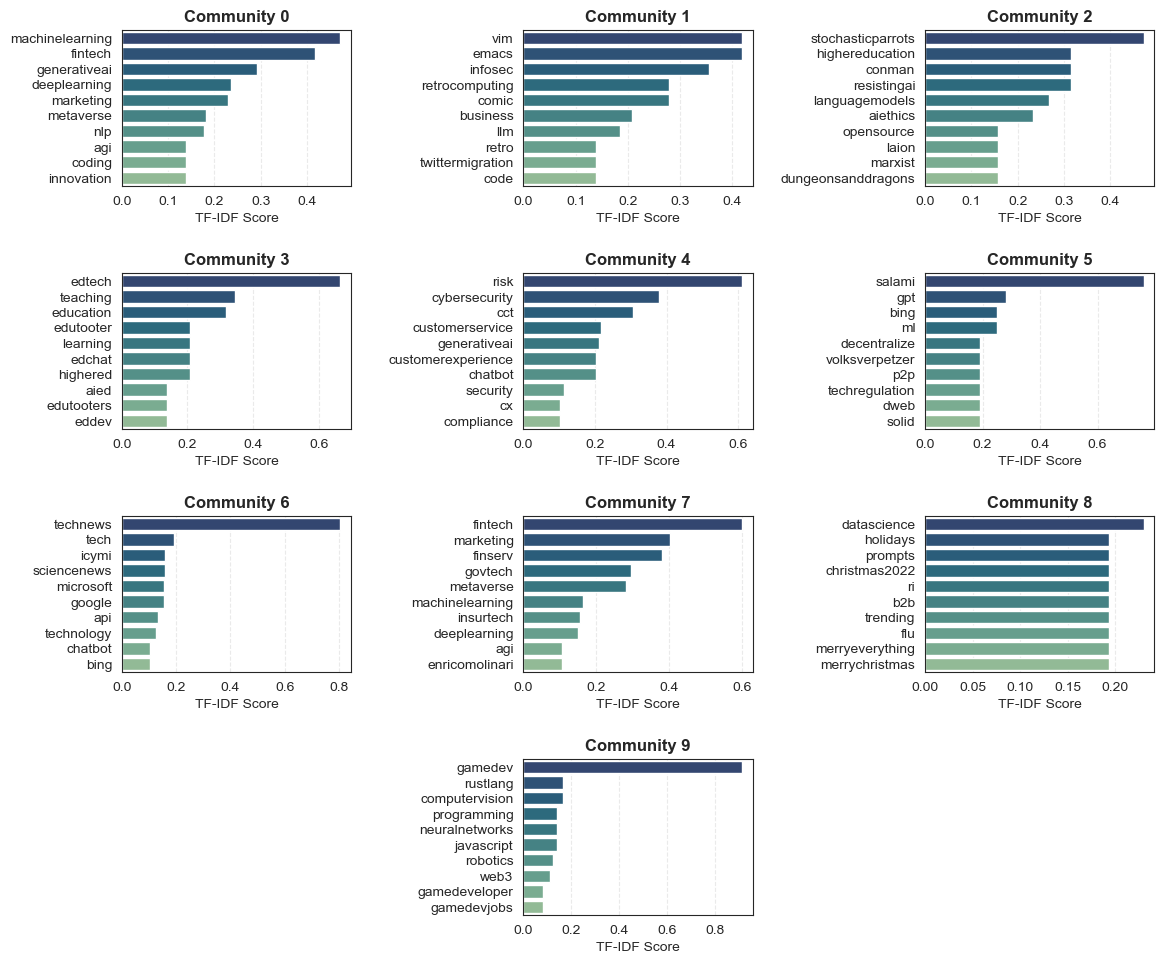

In [69]:
# 1. Configuriamo la griglia generale (3 righe x 4 colonne = 12 spazi totali)
fig = plt.figure(figsize=(12, 10))
grid_size = (4, 3)

# Definiamo le posizioni (row, col) per i 10 grafici
# Prime due righe piene (4+4), terza riga con i due grafici nelle colonne centrali (indice 1 e 2)
positions = []
# Generiamo le prime 9 posizioni (3 righe piene da 3 colonne ciascuna)
for r in range(3):
    for c in range(3):
        positions.append((r, c))
positions.append((3, 1))

for i, cid in enumerate(ids):
    # Creiamo l'asse nella posizione specifica
    ax = plt.subplot2grid(grid_size, positions[i])
    
    # Estraiamo i punteggi TF-IDF (mantenendo la tua logica)
    scores = tfidf_matrix.getrow(i).toarray()[0]
    top_indices = scores.argsort()[-10:][::-1]
    
    df_tfidf = pd.DataFrame({
        'hashtag': [feature_names[idx] for idx in top_indices],
        'score': [scores[idx] for idx in top_indices]
    })
    
    # Generazione del grafico a barre
    if not df_tfidf.empty and df_tfidf['score'].sum() > 0:
        sns.barplot(
            data=df_tfidf, 
            x='score', 
            y='hashtag', 
            ax=ax, 
            hue='hashtag', 
            palette='crest_r',
            legend=False
        )
        ax.set_title(f"Community {cid}", fontsize=12, fontweight='bold')
    else:
        ax.text(0.5, 0.5, "Dati insufficienti", ha='center', va='center')
        ax.set_title(f"Community {cid}")

    # Pulizia estetica
    ax.set_xlabel("TF-IDF Score")
    ax.set_ylabel("")
    ax.grid(axis='x', linestyle='--', alpha=0.4)

# 2. Ottimizzazione finale e salvataggio
plt.tight_layout(pad=2.0)
plt.savefig('report_tfidf_centered.png', dpi=300, bbox_inches='tight')
plt.show()

Le community identificate mostrano interessi tematici chiari e distinti. Alcuni cluster sono fortemente tecnologici e accademici (ID 0, 2, 3, 6, 9), concentrandosi su machine learning, intelligenza artificiale generativa, NLP, edtech, gamedev e strumenti di sviluppo. Altri cluster riflettono interessi professionali e di settore (ID 4, 7), con focus su fintech, marketing, cybersecurity, customer experience e governance tecnologica. Infine, emergono cluster più di nicchia o culturali (ID 1, 2, 5, 8), legati a cultura open source, retrocomputing, fenomeni virali o trend sociali, che mostrano comunità online più specializzate e orientate a hobby o discussioni tematiche specifiche.
In termini di peso relativo (TF-IDF score), si nota che ogni cluster ha uno o due hashtag dominanti, che definiscono chiaramente il tema centrale della community, mentre gli altri hashtag hanno valori più bassi e servono a contestualizzare il focus specifico o a connettere sfumature correlate.

**SENTIMENT**

In identifying the sentiment of a given piece of text, VADER first breaks down the text into individual words. Then, it assigns a score to each word to identify if it is positive or negative. Based on these set scores, VADER finally calculates the overall sentiment score of the text. One crucial thing about VADER is that it also considers the intensity of the sentiment, which is usually altered by capitalization and punctuation. It also searches for modifiers that could change the meaning of neighbor words. This way, it portrays the emotion more effectively.

In [73]:
def clean_tweet(text):
    if pd.isna(text) or text == "":
        return ""
    
    # 1. Rimuovi URL (http, https, www)
    text = re.sub(r'http\S+', 'http', text)
    
    # 2. Rimuovi Menzioni (@user)
    text = re.sub(r'@\w+', '', text)
    
    # 3. Rimuovi il prefisso "RT " tipico dei retweet
    text = re.sub(r'^RT[:\s]+', '', text)
    
    # 4. Rimuovi caratteri speciali inutili (ma tieni punteggiatura ed emoji)
    # Rimuoviamo solo i simboli che possono sporcare (es. &amp; > &)
    #text = text.replace("&amp;", "&")
    #text = text.replace("#", "")
    
    # 5. Rimuovi spazi extra e a capo
    #text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Applichiamo la pulizia prima dell'analisi
df_merged['tweet_clean'] = df_merged['Tweet'].apply(clean_tweet)

In [74]:
# Salva in CSV
df_merged.to_csv('sentiment_data.csv', 
                 index=False, 
                 sep=',', 
                 encoding='utf-8-sig') # 'utf-8-sig' serve per far leggere bene gli accenti a Excel

In [75]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# 1. Inizializzazione VADER
analyzer = SentimentIntensityAnalyzer()

def get_vader_score(text):
    if pd.isna(text) or text == "":
        return 0
    # Restituiamo solo il 'compound' score (bilanciato tra -1 e 1)
    return analyzer.polarity_scores(str(text))['compound']

# 2. Calcolo del sentiment sul DataFrame dei retweet mappati
df_merged['sentiment_score'] = df_merged['tweet_clean'].apply(get_vader_score)

# 3. Aggregazione dei risultati per community
# Calcoliamo media, deviazione standard e numero di tweet per community
community_sentiment_stats = df_merged.groupby('community_id')['sentiment_score'].agg([
    'mean', 
    'std', 
    'count'
]).reset_index()

# Rinominiamo le colonne per chiarezza
community_sentiment_stats.columns = ['community_id', 'sentiment_mean', 'sentiment_std', 'tweet_count']

# 4. Filtriamo solo per le community significative (utilizzando il tuo threshold del 95° percentile)
# Assumiamo che 'significant_df' contenga gli ID delle community sopra la soglia
significant_ids = significant_df['community_id'].unique()
final_analysis = community_sentiment_stats[community_sentiment_stats['community_id'].isin(significant_ids)].copy()

# 5. Classificazione qualitativa del sentiment medio
def label_sentiment(score):
    if score >= 0.05: return 'Positive'
    elif score <= -0.05: return 'Negative'
    else: return 'Neutral'

final_analysis['sentiment_label'] = final_analysis['sentiment_mean'].apply(label_sentiment)

# Ordiniamo per sentiment più positivo
final_analysis = final_analysis.sort_values(by='sentiment_mean', ascending=False)

print("\n Analisi Sentiment Community Significative")
print(final_analysis)


 Analisi Sentiment Community Significative
   community_id  sentiment_mean  sentiment_std  tweet_count sentiment_label
5             5        0.572924       0.487240           17        Positive
9             9        0.288440       0.421075           10        Positive
8             8        0.283140       0.421470           15        Positive
2             2        0.221404       0.475810           28        Positive
4             4        0.189125       0.499526           28        Positive
3             3        0.169522       0.500235           32        Positive
6             6        0.140360       0.266442           15        Positive
0             0        0.135165       0.329029          185        Positive
7             7        0.110018       0.278913          148        Positive
1             1        0.066700       0.556391           28        Positive


In [76]:
#entropia shannon
from scipy.stats import entropy

def calculate_community_entropy(series):
    n_bins = 20
    # Arrotondiamo i valori per creare delle "bin" (es. intervalli di 0.1)
    # Altrimenti ogni punteggio unico verrebbe considerato una categoria a sé
    bins = np.histogram(series, bins=np.linspace(-1, 1, n_bins+1))[0]
    # Normalizziamo per ottenere una distribuzione di probabilità
    probs = bins / bins.sum()
    return entropy(probs)/ np.log(n_bins) if entropy(probs) > 0 else 0

# Calcoliamo l'entropia per ogni community significativa
entropy_df = df_merged.groupby('community_id')['sentiment_score'].apply(calculate_community_entropy).reset_index()
entropy_df.columns = ['community_id', 'sentiment_entropy']

# Uniamola ai tuoi risultati precedenti
final_analysis = final_analysis.merge(entropy_df, on='community_id')
print(final_analysis[['community_id', 'sentiment_mean', 'sentiment_entropy']].sort_values(by='sentiment_entropy'))

   community_id  sentiment_mean  sentiment_entropy
0             5        0.572924           0.439177
6             6        0.140360           0.560532
8             7        0.110018           0.594211
1             9        0.288440           0.612328
2             8        0.283140           0.676372
5             3        0.169522           0.684127
4             4        0.189125           0.692771
7             0        0.135165           0.696157
3             2        0.221404           0.739127
9             1        0.066700           0.795292


L'entropia misura la casualità o l'impurità nella classificazione dei sentimenti: un'entropia più elevata indica maggiore incertezza.
La community 5 presenta un elevanto valore del sentiment e il più basso valore di entropia: hanno una visione positiva e simile del tema. Un gruppo coeso (potrebbe essere isolato dalle opinioni contrastanti).
Community 6 e 7 hanno un valore di entropia medio-bassa ma il sentiment è molto vicino allo zero. C'è più discussione (la community 7 è anche una di quelle più ampie).
Per la community 1 il sentimento è quasi neutro, con un'entropia elevata -> frammentazione. La community 1 è aperta, l'opposto di una camera dell'eco.
La community 0 è la più ampia, con un'entropia alta e un sentiment positivo ma basso -> opinioni molto diverse

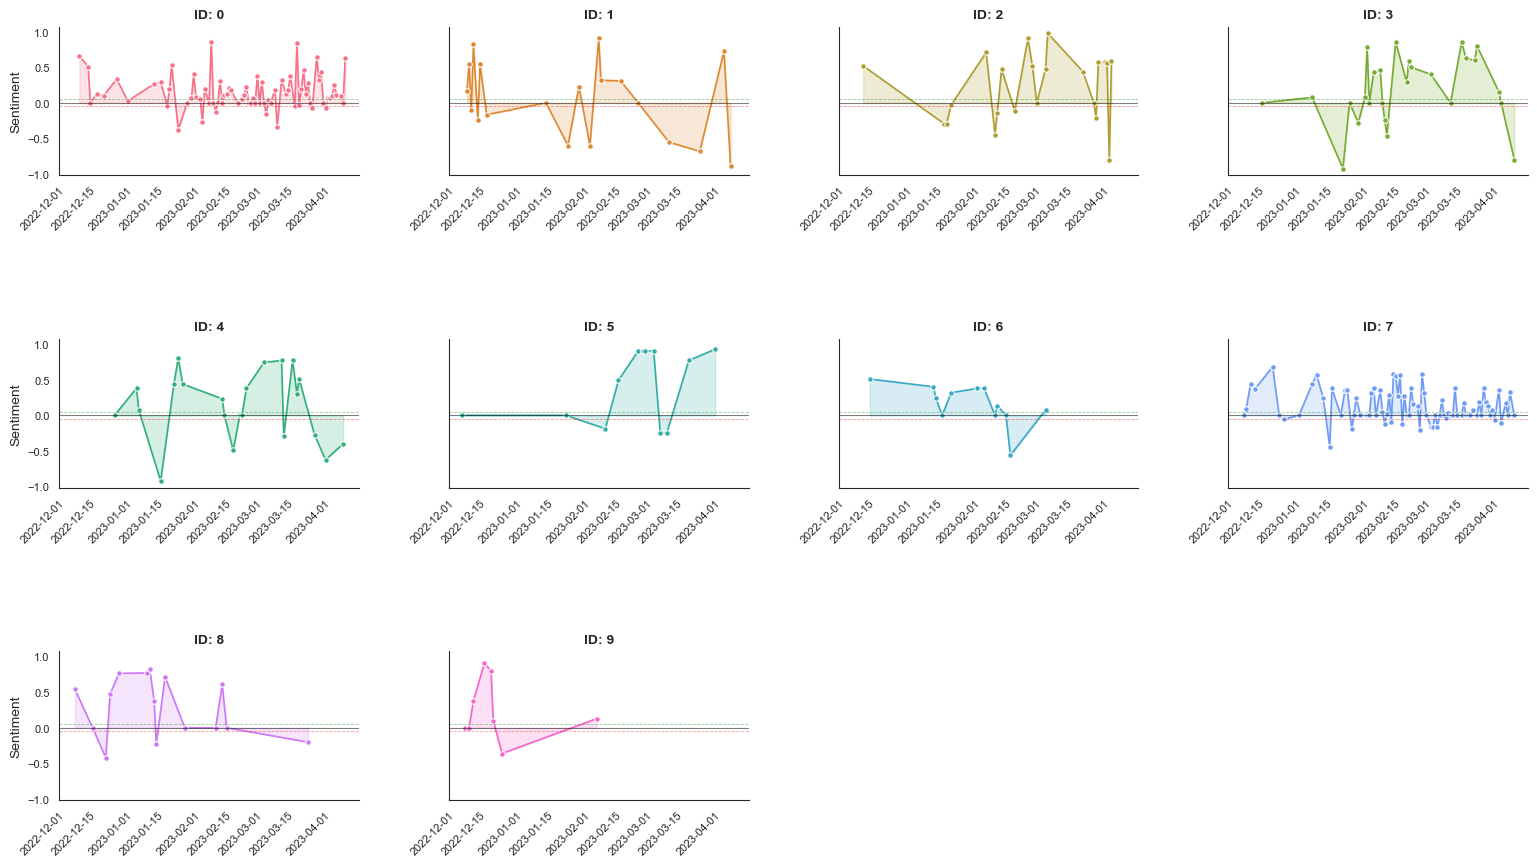

In [78]:
# 1. Preparazione dei dati e filtro community significative
df_plot = df_merged.reset_index()
df_plot['Day'] = pd.to_datetime(df_plot['Date']).dt.date 

significant_ids = significant_df['community_id'].unique()
grid_data = df_plot.groupby(['Day', 'community_id'])['sentiment_score'].mean().reset_index()
grid_data_filtered = grid_data[grid_data['community_id'].isin(significant_ids)].copy()

# 2. Creazione della FacetGrid con col_wrap=4
# Avendo 4 colonne, riduciamo height e aspect per non far uscire il grafico dallo schermo
g = sns.FacetGrid(grid_data_filtered, col="community_id", col_wrap=4, 
                  hue="community_id", palette="husl", 
                  height=3, aspect=1.3) 

# 3. Mappatura dei grafici
g.map(plt.fill_between, "Day", "sentiment_score", alpha=0.2)
g.map(sns.lineplot, "Day", "sentiment_score", marker="o", linewidth=1.2, markersize=4)

# 4. Raffinatezze estetiche
g.set_axis_labels("", "Sentiment")
g.set_titles("ID: {col_name}", fontweight='bold', size=10)

for ax in g.axes.flat:
    ax.tick_params(labelbottom=True, labelsize=8) 
    
    # Linee di riferimento (Neutral, Positive threshold, Negative threshold)
    ax.axhline(0, color='black', linewidth=0.8, alpha=.5)
    ax.axhline(0.05, color='green', linestyle='--', linewidth=0.6, alpha=.4)
    ax.axhline(-0.05, color='red', linestyle='--', linewidth=0.6, alpha=.4)
    
    # Ruotiamo le date
    plt.setp(ax.get_xticklabels(), rotation=45, horizontalalignment='right')

# Aumentiamo lo spazio per far leggere bene le date tra le righe
plt.subplots_adjust(hspace=1.1, wspace=0.3, top=0.92)
plt.savefig('sent_retweet.png', dpi=300, bbox_inches='tight')
plt.show()

**roBERTa**

In [80]:
bert_df=pd.read_csv('BERT_sent.csv')

In [81]:
merged_df = pd.merge(bert_df, significant_df[['community_id']], on='community_id', how='inner')

# 6. Aggregazione: calcolo media e conteggio
community_sentiment = merged_df.groupby('community_id')['sentiment_numeric'].agg([
    ('sentiment_medio', 'mean'),
    ('sentiment_std', 'std'),
    ('sentiment_entropy', calculate_community_entropy),
    ('n_tweet', 'count')
]).reset_index()
community_sentiment.columns = ['community_id', 'sentiment_medio','sentiment_std', 'sentiment_entropy', 'n_tweet']

# 7. AGGIUNTA COLONNA COMPLESSIVA (con soglia per il Neutro)
# Un valore tra -0.1 e 0.1 può essere considerato Neutro
def definisci_sentiment_finale(media):
    if media > 0.05:
        return 'Positivo'
    elif media < -0.05:
        return 'Negativo'
    else:
        return 'Neutro'

community_sentiment['sentiment_complessivo'] = community_sentiment['sentiment_medio'].apply(definisci_sentiment_finale)

# 8. Unione con i dati originali (significant_df)
final_results = (pd.merge(community_sentiment, significant_df, on='community_id')).round(4)

# Ordiniamo per vedere le più polarizzate
final_results = final_results.sort_values(by='sentiment_medio', ascending=False)

print(final_results[['community_id', 'sentiment_medio', 'sentiment_std', 'sentiment_entropy', 'sentiment_complessivo', 'n_tweet']])

   community_id  sentiment_medio  sentiment_std  sentiment_entropy  \
9             9           0.2781         0.5122             0.3900   
8             8           0.2069         0.5289             0.5700   
5             5           0.1372         0.6078             0.4558   
3             3           0.1111         0.4664             0.4876   
6             6           0.0640         0.3565             0.3299   
4             4           0.0215         0.5287             0.5106   
7             7          -0.0209         0.3116             0.3204   
0             0          -0.0365         0.3510             0.3896   
1             1          -0.0825         0.5611             0.5877   
2             2          -0.1585         0.4933             0.5929   

  sentiment_complessivo  n_tweet  
9              Positivo       10  
8              Positivo       15  
5              Positivo       17  
3              Positivo       32  
6              Positivo       15  
4                Ne

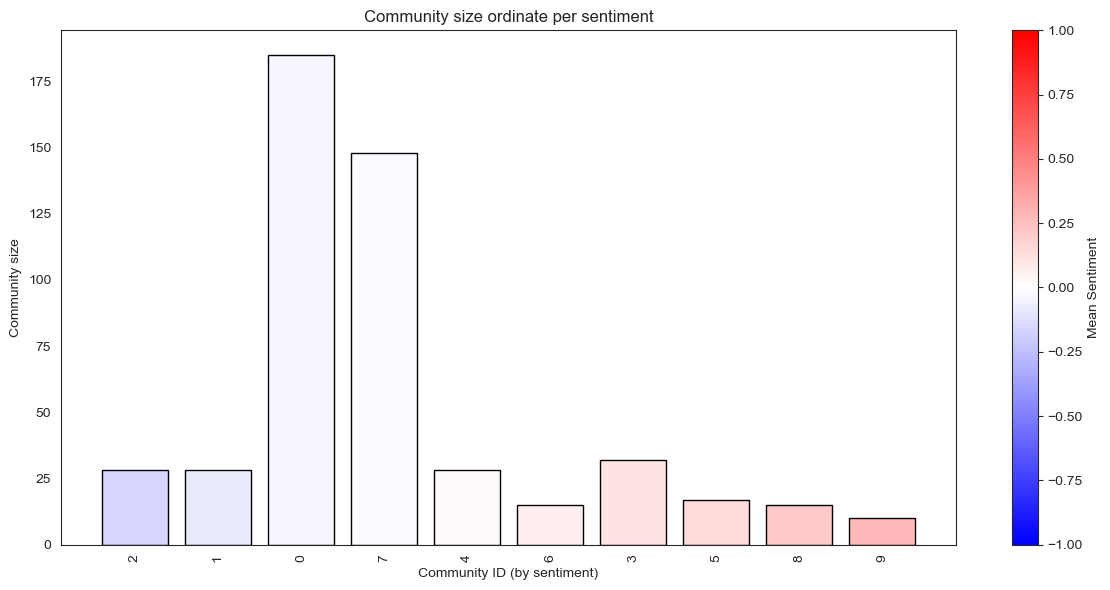

In [91]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Ordina per sentiment
plot_df = final_results.sort_values("sentiment_medio")

x = plot_df["community_id"]
y = plot_df["n_tweet"]
sentiment = plot_df["sentiment_medio"]

cmap = plt.cm.bwr
norm = mcolors.TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)

colors = cmap(norm(sentiment))

fig, ax = plt.subplots(figsize=(12,6))

bars = ax.bar(
    range(len(x)),
    y,
    color=colors,
    edgecolor="black"
)

ax.set_xticks(range(len(x)))
ax.set_xticklabels(x, rotation=90)

ax.set_xlabel("Community ID (by sentiment)")
ax.set_ylabel("Community size")
ax.set_title("Community size ordinate per sentiment")
ax.grid(False)

# colorbar corretta
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

fig.colorbar(sm, ax=ax, label="Mean Sentiment")

plt.tight_layout()
plt.savefig('sent_compl.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# 1. Preparazione dei dati e filtro community significative
df_plot = merged_df.reset_index()
df_plot['Day'] = pd.to_datetime(df_plot['Date']).dt.date 

significant_ids = significant_df['community_id'].unique()
grid_data = df_plot.groupby(['Day', 'community_id'])['sentiment_numeric'].mean().reset_index()
grid_data_filtered = grid_data[grid_data['community_id'].isin(significant_ids)].copy()

# 2. Creazione della FacetGrid con col_wrap=4
# Avendo 4 colonne, riduciamo height e aspect per non far uscire il grafico dallo schermo
g = sns.FacetGrid(grid_data_filtered, col="community_id", col_wrap=4, 
                  hue="community_id", palette="husl", 
                  height=3, aspect=1.3) 

# 3. Mappatura dei grafici
g.map(plt.fill_between, "Day", "sentiment_numeric", alpha=0.2)
g.map(sns.lineplot, "Day", "sentiment_numeric", marker="o", linewidth=1.2, markersize=4)

# 4. Raffinatezze estetiche
g.set_axis_labels("", "Sentiment")
g.set_titles("ID: {col_name}", fontweight='bold', size=10)

for ax in g.axes.flat:
    ax.tick_params(labelbottom=True, labelsize=8) 
    
    # Linee di riferimento (Neutral, Positive threshold, Negative threshold)
    ax.axhline(0, color='black', linewidth=0.8, alpha=.5)
    ax.axhline(0.05, color='green', linestyle='--', linewidth=0.6, alpha=.4)
    ax.axhline(-0.05, color='red', linestyle='--', linewidth=0.6, alpha=.4)
    
    # Ruotiamo le date
    plt.setp(ax.get_xticklabels(), rotation=45, horizontalalignment='right')

# Aumentiamo lo spazio per far leggere bene le date tra le righe
plt.subplots_adjust(hspace=1.1, wspace=0.3, top=0.92)
plt.savefig('BERT_retweet.png', dpi=300, bbox_inches='tight')
plt.show()

**Gruppo controllo random**

In [473]:
import numpy as np
import igraph as ig
import leidenalg as la
from tqdm import tqdm
import random

# ==========================================
# 1. SETUP PER RIPRODUCIBILITÀ (SEED)
# ==========================================
SEED = 29
random.seed(SEED)
np.random.seed(SEED)
# Imposta il generatore interno di igraph
ig.set_random_number_generator(random.Random(SEED))

# ==========================================
# 2. PARAMETRI RETE REALE
# ==========================================
# Assicurati che g_ig_rt sia definito prima di questo blocco
# Esempio placeholder se non lo hai caricato:
# g = ig.Graph.Erdos_Renyi(n=100, m=200, directed=True) 
g = g_ig_rt  

N = g.vcount()
M = g.ecount()
iterazioni = 100

print(f"Simulazione su {iterazioni} grafi random (Erdos-Renyi G(n,m))")
print(f"Nodi: {N} | Archi: {M}")

# -----------------------------
# LISTE METRICHE RANDOM
# -----------------------------
random_modularity = []
random_clustering = []
random_betweenness = []

# ==========================================
# 3. SIMULAZIONE (LOOP)
# ==========================================
for i in tqdm(range(iterazioni)):

    # 1. Generazione grafo random Erdos-Renyi (G, n, m)
    # Grazie al seed globale di igraph, questa sequenza sarà sempre la stessa
    G_rand = ig.Graph.Erdos_Renyi(n=N, m=M, directed=True)

    # Conversione per metriche che richiedono grafi non diretti
    G_rand_undir = G_rand.as_undirected(mode="collapse")

    # --- CLUSTERING ---
    try:
        clust = G_rand_undir.transitivity_avglocal_undirected()
        random_clustering.append(clust)
    except:
        random_clustering.append(0)

    # --- BETWEENNESS ---
    try:
        if N < 5000:
            betw = np.mean(G_rand.betweenness())
        else:
            # Campionamento deterministico con numpy seed
            sample_nodes = np.random.choice(N, 500, replace=False)
            betw = np.mean(G_rand.betweenness(vertices=sample_nodes))
        random_betweenness.append(betw)
    except:
        random_betweenness.append(0)

    # --- MODULARITY (LEIDEN) ---
    try:
        if G_rand_undir.ecount() > 0:
            # Il seed interno di Leiden garantisce che l'ottimizzazione sia la stessa
            partition = la.find_partition(
                G_rand_undir,
                la.ModularityVertexPartition,
                seed=SEED
            )
            random_modularity.append(partition.modularity)
        else:
            random_modularity.append(0)
    except:
        random_modularity.append(0)

# ==========================================
# 4. METRICHE GRAFO REALE
# ==========================================
# Calcoliamo le stesse metriche sul grafo originale per il confronto
# Nota: final_partition_object deve essere la partizione calcolata sul tuo g originale
orig_modularity = final_partition_object.modularity 
orig_clustering = g.as_undirected(mode="collapse").transitivity_avglocal_undirected()
orig_betweenness = np.mean(g.betweenness())

# ==========================================
# 5. FUNZIONE DI CONFRONTO, Z-SCORE E P-VALUE
# ==========================================

def compare_metric(name, real_value, random_values):
    vals = np.array(random_values)
    mean_rand = np.mean(vals)
    std_rand = np.std(vals)
    n_sim = len(vals)

    # 1. Calcolo Z-score
    z_score = (real_value - mean_rand) / std_rand if std_rand > 0 else 0

    # 2. Calcolo P-value Empirico (Two-tailed)
    # Contiamo quante volte il valore random è più distante dalla media rispetto al valore reale
    # Usiamo la formula (count + 1) / (n + 1) per evitare p-value pari a 0.0
    distance_real = abs(real_value - mean_rand)
    outlier_count = np.sum(np.abs(vals - mean_rand) >= distance_real)
    p_value = (outlier_count + 1) / (n_sim + 1)

    print("\n" + "="*40)
    print(f"{name.upper()}")
    print("="*40)
    print(f"Valore Reale:    {real_value:.6f}")
    print(f"Media Random:    {mean_rand:.6f} ± {std_rand:.6f}")
    print(f"Z-score:         {z_score:.2f}")
    print(f"P-value:         {p_value:.4f}")

    # Interpretazione combinata
    if p_value <= 0.05:
        sig_status = "SIGNIFICATIVO"
        if z_score > 0:
            detail = "molto superiore al caso"
        else:
            detail = "molto inferiore al caso"
    else:
        sig_status = "NON SIGNIFICATIVO"
        detail = "compatibile con fluttuazioni casuali"

    print(f"Risultato:       {sig_status} ({detail})")

# ==========================================
# 6. STAMPA RISULTATI FINALI
# ==========================================

compare_metric("Modularity", orig_modularity, random_modularity)
compare_metric("Clustering coefficient", orig_clustering, random_clustering)
compare_metric("Average betweenness", orig_betweenness, random_betweenness)

print("\n" + "-"*40)
print(f"Density reale:   {g.density():.6f}")
print(f"Average degree:  {np.mean(g.degree()):.2f}")

Simulazione su 100 grafi random (Erdos-Renyi G(n,m))
Nodi: 665 | Archi: 524


100%|██████████| 100/100 [00:01<00:00, 90.48it/s]


MODULARITY
Valore Reale:    0.931341
Media Random:    0.872792 ± 0.009614
Z-score:         6.09
P-value:         0.0099
Risultato:       SIGNIFICATIVO (molto superiore al caso)

CLUSTERING COEFFICIENT
Valore Reale:    0.008289
Media Random:    0.001965 ± 0.002687
Z-score:         2.35
P-value:         0.0495
Risultato:       SIGNIFICATIVO (molto superiore al caso)

AVERAGE BETWEENNESS
Valore Reale:    0.007519
Media Random:    10.339985 ± 8.299320
Z-score:         -1.24
P-value:         0.0891
Risultato:       NON SIGNIFICATIVO (compatibile con fluttuazioni casuali)

----------------------------------------
Density reale:   0.001187
Average degree:  1.58


✅ Grafico con campana salvato: modularity_result.png


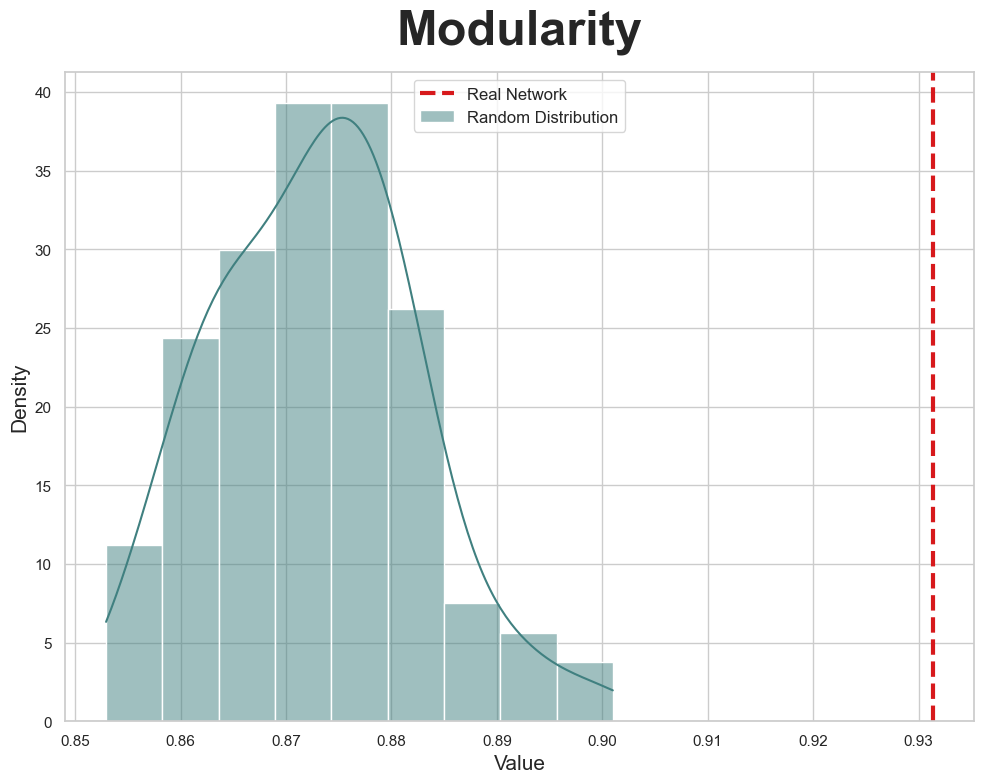

✅ Grafico con campana salvato: clustering_result.png


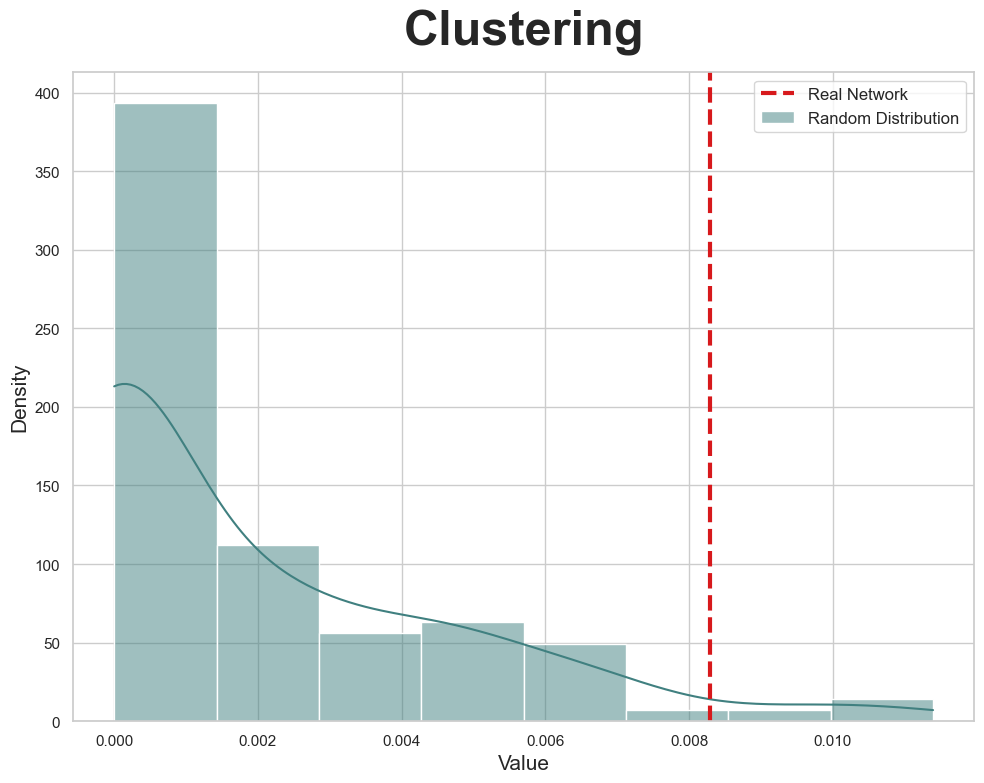

✅ Grafico con campana salvato: betweenness_result.png


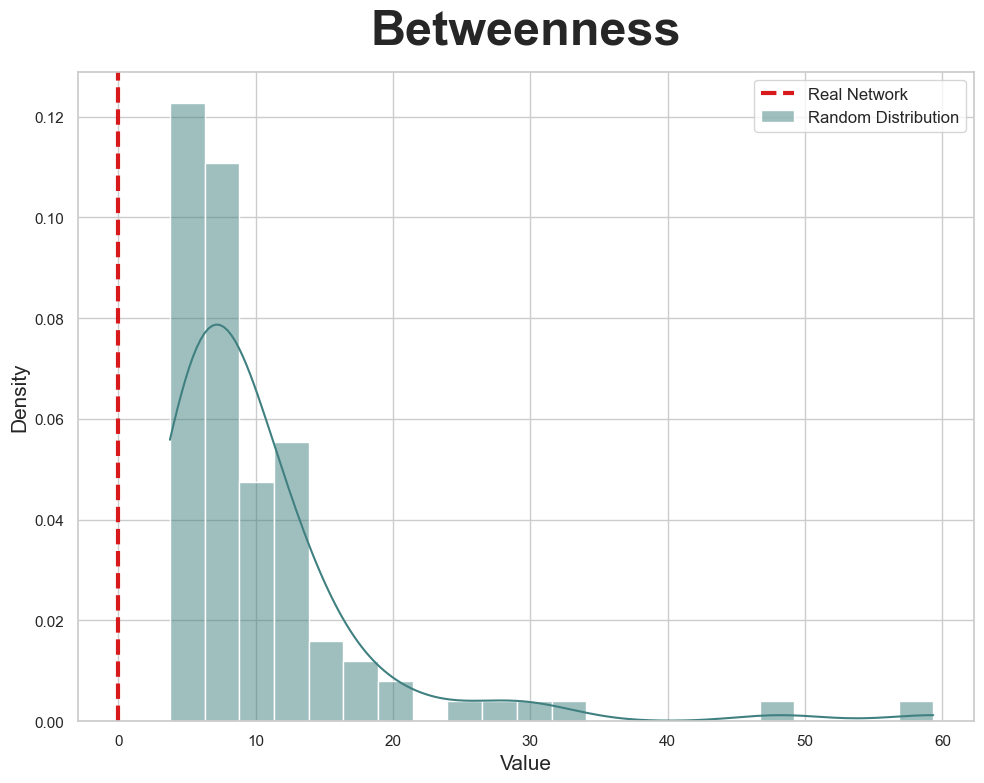

In [479]:
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import numpy as np

def plot_distribution(random_values, real_value, title):
    # Setup estetico
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(10, 8))
    
    # 1. DISEGNO ISTOGRAMMA + CAMPANA (KDE)
    # stat="density" serve per avere la curva sulla stessa scala dell'istogramma
    sns.histplot(random_values, kde=True, color="#408080", 
                 stat="density", label="Random Distribution", alpha=0.5)
    
    # 2. LINEA REALE
    plt.axvline(real_value, linestyle="--", linewidth=3, color="#D7191C",
                label=f"Real Network")
    
    # 3. TITOLO E ETICHETTE
    plt.title(title, fontsize=35, fontweight='bold', pad=20)
    plt.xlabel("Value", fontsize=15)
    plt.ylabel("Density", fontsize=15)
    plt.legend(fontsize=12)
    
    # 4. OTTIMIZZAZIONE SPAZI E SALVATAGGIO
    plt.tight_layout()
    clean_name = title.lower().replace(" ", "_")
    filename = f"{clean_name}_result.png"
    plt.savefig(filename, dpi=300)
    
    print(f"✅ Grafico con campana salvato: {filename}")
    plt.show()

# Esempio di chiamata
plot_distribution(random_modularity, orig_modularity, "Modularity")
plot_distribution(random_clustering, orig_clustering, "Clustering")
plot_distribution(random_betweenness, orig_betweenness, "Betweenness")

In [464]:
def get_boxplot_stats(data, name):
    data = np.array(data)
    q1 = np.percentile(data, 25)
    median = np.percentile(data, 50)
    q3 = np.percentile(data, 75)
    iqr = q3 - q1
    
    # Calcolo dei baffi (Whiskers)
    lower_whisker = data[data >= q1 - 1.5 * iqr].min()
    upper_whisker = data[data <= q3 + 1.5 * iqr].max()
    
    # Identificazione Outlier
    outliers = data[(data < q1 - 1.5 * iqr) | (data > q3 + 1.5 * iqr)]
    
    print(f"\n--- STATISTICHE BOXPLOT: {name.upper()} ---")
    print(f"Minimo (Baffo inf): {lower_whisker:.6f}")
    print(f"Q1 (25th):          {q1:.6f}")
    print(f"Mediana (50th):     {median:.6f}")
    print(f"Q3 (75th):          {q3:.6f}")
    print(f"Massimo (Baffo sup): {upper_whisker:.6f}")
    print(f"IQR:                {iqr:.6f}")
    print(f"Num. Outlier:       {len(outliers)} su {len(data)}")
    if len(outliers) > 0:
        print(f"Esempi Outlier:     {outliers[:5]}") # Mostra i primi 5
    return {
        "q1": q1, "median": median, "q3": q3, 
        "lw": lower_whisker, "uw": upper_whisker
    }

# Esempio di utilizzo:
stats_mod = get_boxplot_stats(random_modularity, "Modularity")
stats_clust = get_boxplot_stats(random_clustering, "Clustering")
stats_clust = get_boxplot_stats(random_betweenness, "Betweenness")


--- STATISTICHE BOXPLOT: MODULARITY ---
Minimo (Baffo inf): 0.852923
Q1 (25th):          0.864995
Mediana (50th):     0.873189
Q3 (75th):          0.878845
Massimo (Baffo sup): 0.897446
IQR:                0.013850
Num. Outlier:       1 su 100
Esempi Outlier:     [0.90099587]

--- STATISTICHE BOXPLOT: CLUSTERING ---
Minimo (Baffo inf): 0.000000
Q1 (25th):          0.000000
Mediana (50th):     0.000000
Q3 (75th):          0.003362
Massimo (Baffo sup): 0.007051
IQR:                0.003362
Num. Outlier:       4 su 100
Esempi Outlier:     [0.01139241 0.01021505 0.00980392 0.0085197 ]

--- STATISTICHE BOXPLOT: BETWEENNESS ---
Minimo (Baffo inf): 3.768421
Q1 (25th):          5.805639
Mediana (50th):     7.717293
Q3 (75th):          11.705639
Massimo (Baffo sup): 18.449624
IQR:                5.900000
Num. Outlier:       8 su 100
Esempi Outlier:     [28.51428571 20.98045113 48.17443609 59.33233083 20.77293233]
